In [35]:
from pathlib import Path
import sys
import warnings

# Resolve the project root whether the notebook is run from /notebooks or the repo root.
CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Cannot locate project root containing the src/ directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "Student_Performance.csv"
MODELS_DIR = PROJECT_ROOT / "models"

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\A Fee\Desktop\Workspace\AI_projects\Student_Performance_Predictor


In [36]:
import json
import math
from functools import partial

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

from src.feature_engineering import add_new_features, feature_engineering_for_pipeline

set_config(transform_output="pandas")
sns.set_theme(style="whitegrid")


# Notebook Goal
Notebook này ghi lại workflow modeling end-to-end cho Student Performance Predictor:

- inspect và clean dữ liệu tabular
- split train/test trước EDA để giảm leakage risk
- chỉ dùng training set cho EDA và feature-selection diagnostics
- xây preprocessing pipeline và model comparison
- chọn final pipeline có thể deploy bằng scikit-learn/joblib

Phase 1 cleanup giữ nguyên hướng modeling chính. Artifact export được tắt mặc định để tránh overwrite model trong lúc dọn notebook.


# 1. Data Loading


In [37]:
df = pd.read_csv(DATA_PATH)
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# 2. Data Cleaning
Cleaning ở phase này cố tình conservative: bỏ exact duplicates và enforce upper bound cho target score. Các outlier khác chưa bị xóa tự động nếu chưa có domain rule rõ ràng.


In [38]:
df.shape


(6607, 20)

In [39]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [40]:
df.describe()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [41]:
top1_students = df[df['Exam_Score'].between(90, 100)]
print(f"Số lượng sinh viên đạt điểm từ 90 - 100: {len(top1_students)}")
top2_students = df[df['Exam_Score'].between(80,89)]
print(f"Số lượng sinh viên đạt điểm từ 80 - 89: {len(top2_students)}")
top3_students = df[df['Exam_Score'].between(70,79)]
print(f"Số lượng sinh viên đạt điểm từ 70 - 79: {len(top3_students)}")
top4_students = df[df['Exam_Score'] < 70]
print(f"Số lượng sinh viên đạt điểm < 70: {len(top4_students)}")


Số lượng sinh viên đạt điểm từ 90 - 100: 21
Số lượng sinh viên đạt điểm từ 80 - 89: 26
Số lượng sinh viên đạt điểm từ 70 - 79: 1577
Số lượng sinh viên đạt điểm < 70: 4982


In [42]:
df = df.drop_duplicates()
df = df[df['Exam_Score'] <= 100]
df.isnull().sum()


Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

# 3. Train/Test Split
Split được thực hiện trước EDA, feature selection và model comparison. Cách này giữ test set như holdout độc lập, tránh để quyết định exploratory học từ evaluation data.


In [43]:
# Keep the raw split for the deployable sklearn Pipeline.
X = df.drop(columns="Exam_Score")
y = df["Exam_Score"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# Analysis copies are used for EDA and feature-selection diagnostics only.
# The final deployable pipeline applies the same feature engineering internally.
X_train_analysis = add_new_features(X_train_raw.copy())
X_test_analysis = add_new_features(X_test_raw.copy())

print(f"Raw train shape: {X_train_raw.shape}")
print(f"Engineered train shape: {X_train_analysis.shape}")
print(f"Duplicated rows in engineered train: {X_train_analysis.duplicated().sum()}")


Raw train shape: (5284, 19)
Engineered train shape: (5284, 22)
Duplicated rows in engineered train: 0


In [44]:
new_engineered_features = ["Study_Efficiency", "Total_Study_Time", "Engagement_Index"]
original_num = X_train_analysis.select_dtypes(include=["number"]).columns.tolist()

num_features_raw = [col for col in original_num if col not in new_engineered_features]
full_num_features = num_features_raw + new_engineered_features

bin_features_master = [
    "Extracurricular_Activities",
    "Internet_Access",
    "Learning_Disabilities",
    "Gender",
    "School_Type",
]

ord_features_master = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality",
    "Peer_Influence",
    "Parental_Education_Level",
    "Distance_from_Home",
]

ord_categories_master = [["missing", "Low", "Medium", "High"]] * 5 + [
    ["missing", "Negative", "Neutral", "Positive"],
    ["missing", "High School", "College", "Postgraduate"],
    ["missing", "Near", "Moderate", "Far"],
]

print(
    "Feature groups initialized: "
    f"{len(full_num_features)} numeric, "
    f"{len(ord_features_master)} ordinal, "
    f"{len(bin_features_master)} binary/nominal."
)


Feature groups initialized: 9 numeric, 8 ordinal, 5 binary/nominal.


## Phân chia các đặc trưng phân loại và đặc trưng số


In [45]:
num_features = X_train_analysis.select_dtypes(include=np.number).columns
cat_features = X_train_analysis.select_dtypes(exclude=np.number).columns

print("Danh sách các đặc trưng số: ", num_features)
print("Danh sách các đặc trưng phân loại: ", cat_features)


Danh sách các đặc trưng số:  Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Study_Efficiency',
       'Total_Study_Time', 'Engagement_Index'],
      dtype='object')
Danh sách các đặc trưng phân loại:  Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


# 4. Exploratory Data Analysis
EDA chỉ dùng training split. Mục tiêu là tìm distribution issues, target relationships, encoding needs và feature-selection signals, không phải tạo thật nhiều chart cho đẹp.


## Target and Numeric Distributions
Các histogram này cho thấy phân phối target và numeric predictors. Chúng hỗ trợ quyết định scaling và phát hiện giá trị cực trị cần review. Đây là descriptive EDA, còn preprocessing cuối vẫn được fit bằng sklearn transformers.


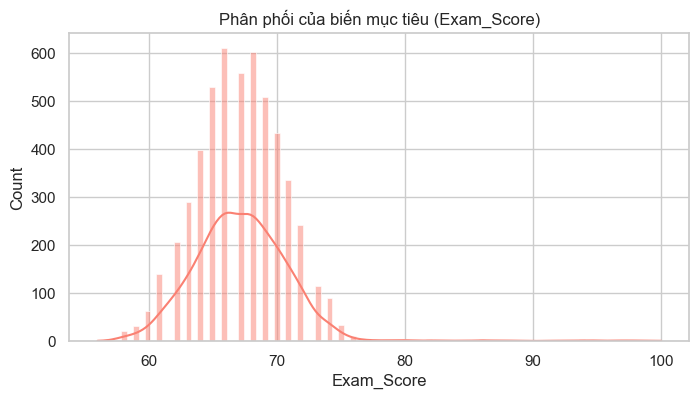

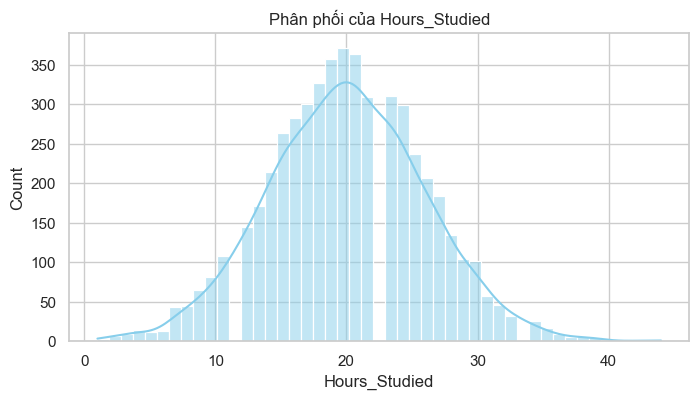

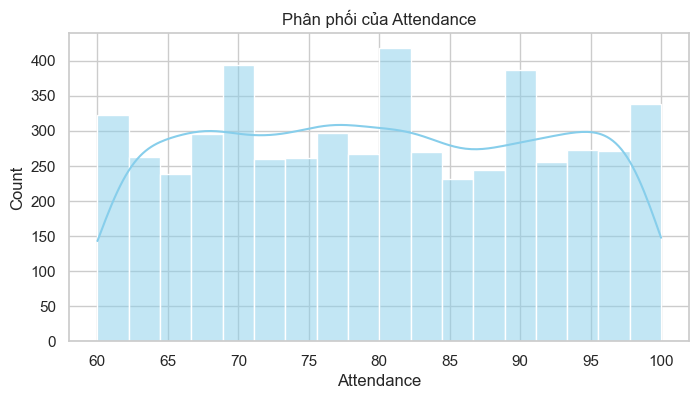

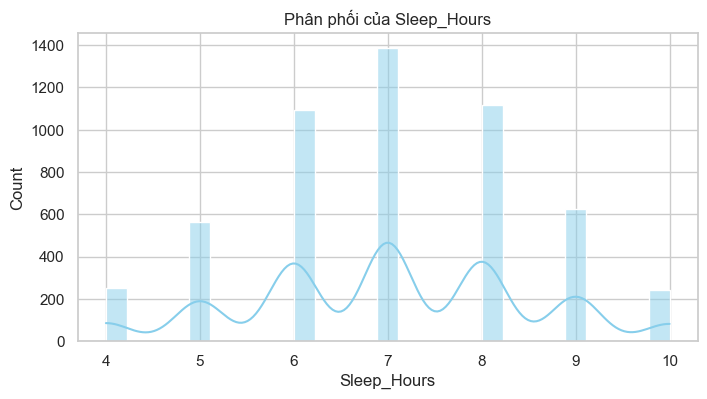

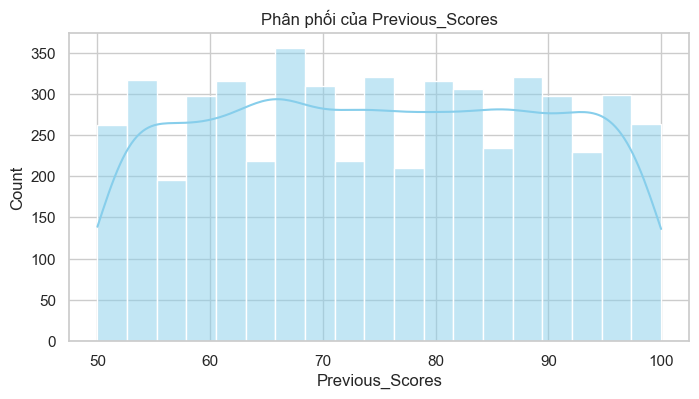

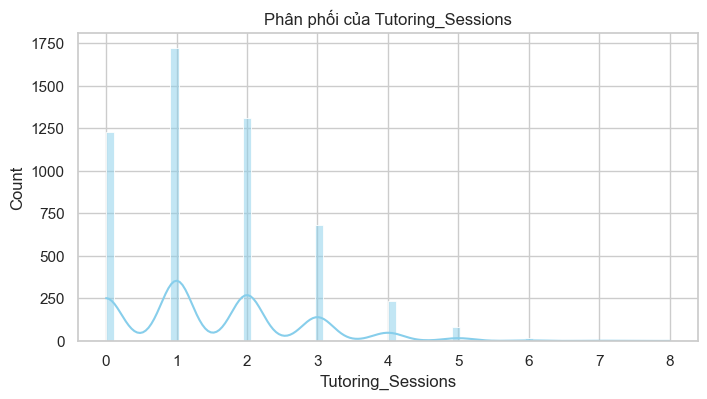

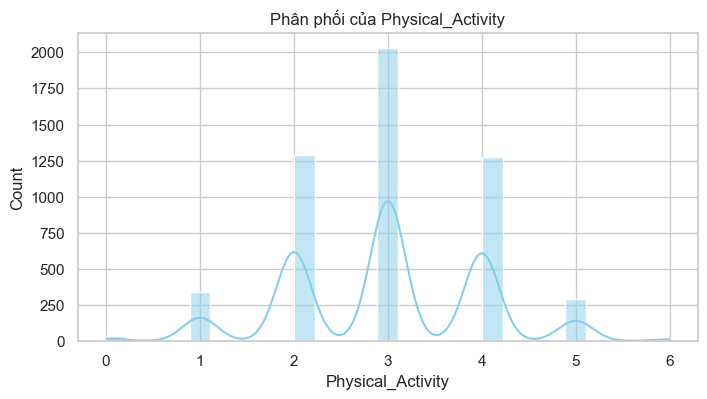

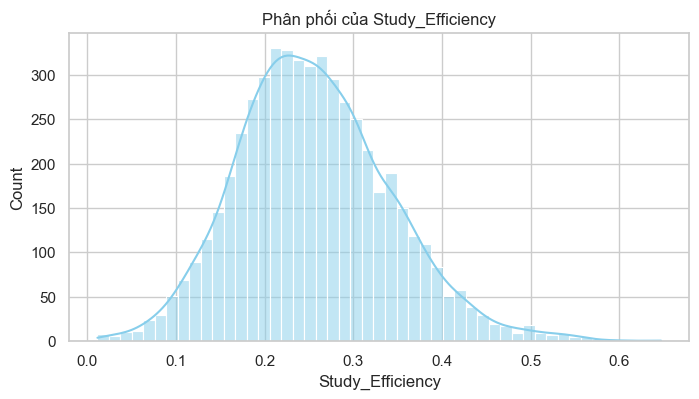

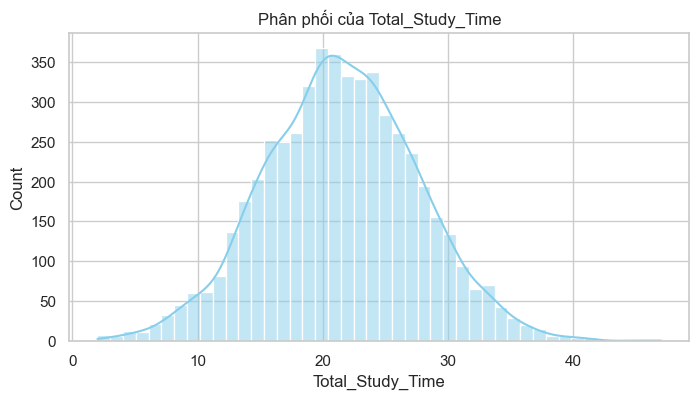

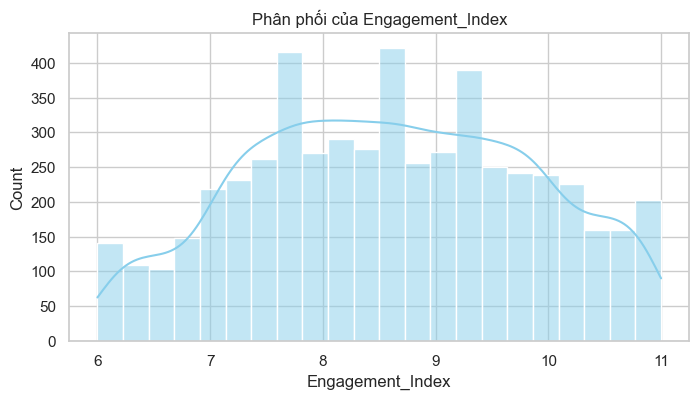

In [46]:
# 1. Vẽ biến mục tiêu trước
plt.figure(figsize=(8, 4))
sns.histplot(y_train, kde=True, color='salmon')
plt.title("Phân phối của biến mục tiêu (Exam_Score)")
plt.show()

# 2. Lặp qua danh sách TỔNG (full_num_features) để không sót cột nào
for i in num_features:
    # Kiểm tra xem cột i có thực sự nằm trong DataFrame không để tránh lỗi
    if i in X_train_analysis.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(X_train_analysis[i], kde=True, color='skyblue')
        plt.title(f"Phân phối của {i}")
        plt.show()
    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy cột {i} trong X_train_analysis")


## Categorical Feature Frequencies
Count plots giúp kiểm tra category imbalance và rare categories trước khi encoding. Nếu category hiếm hoặc missing xuất hiện, one-hot columns có thể kém ổn định trên holdout split. Insight này hỗ trợ dùng imputer và handle_unknown trong encoder.


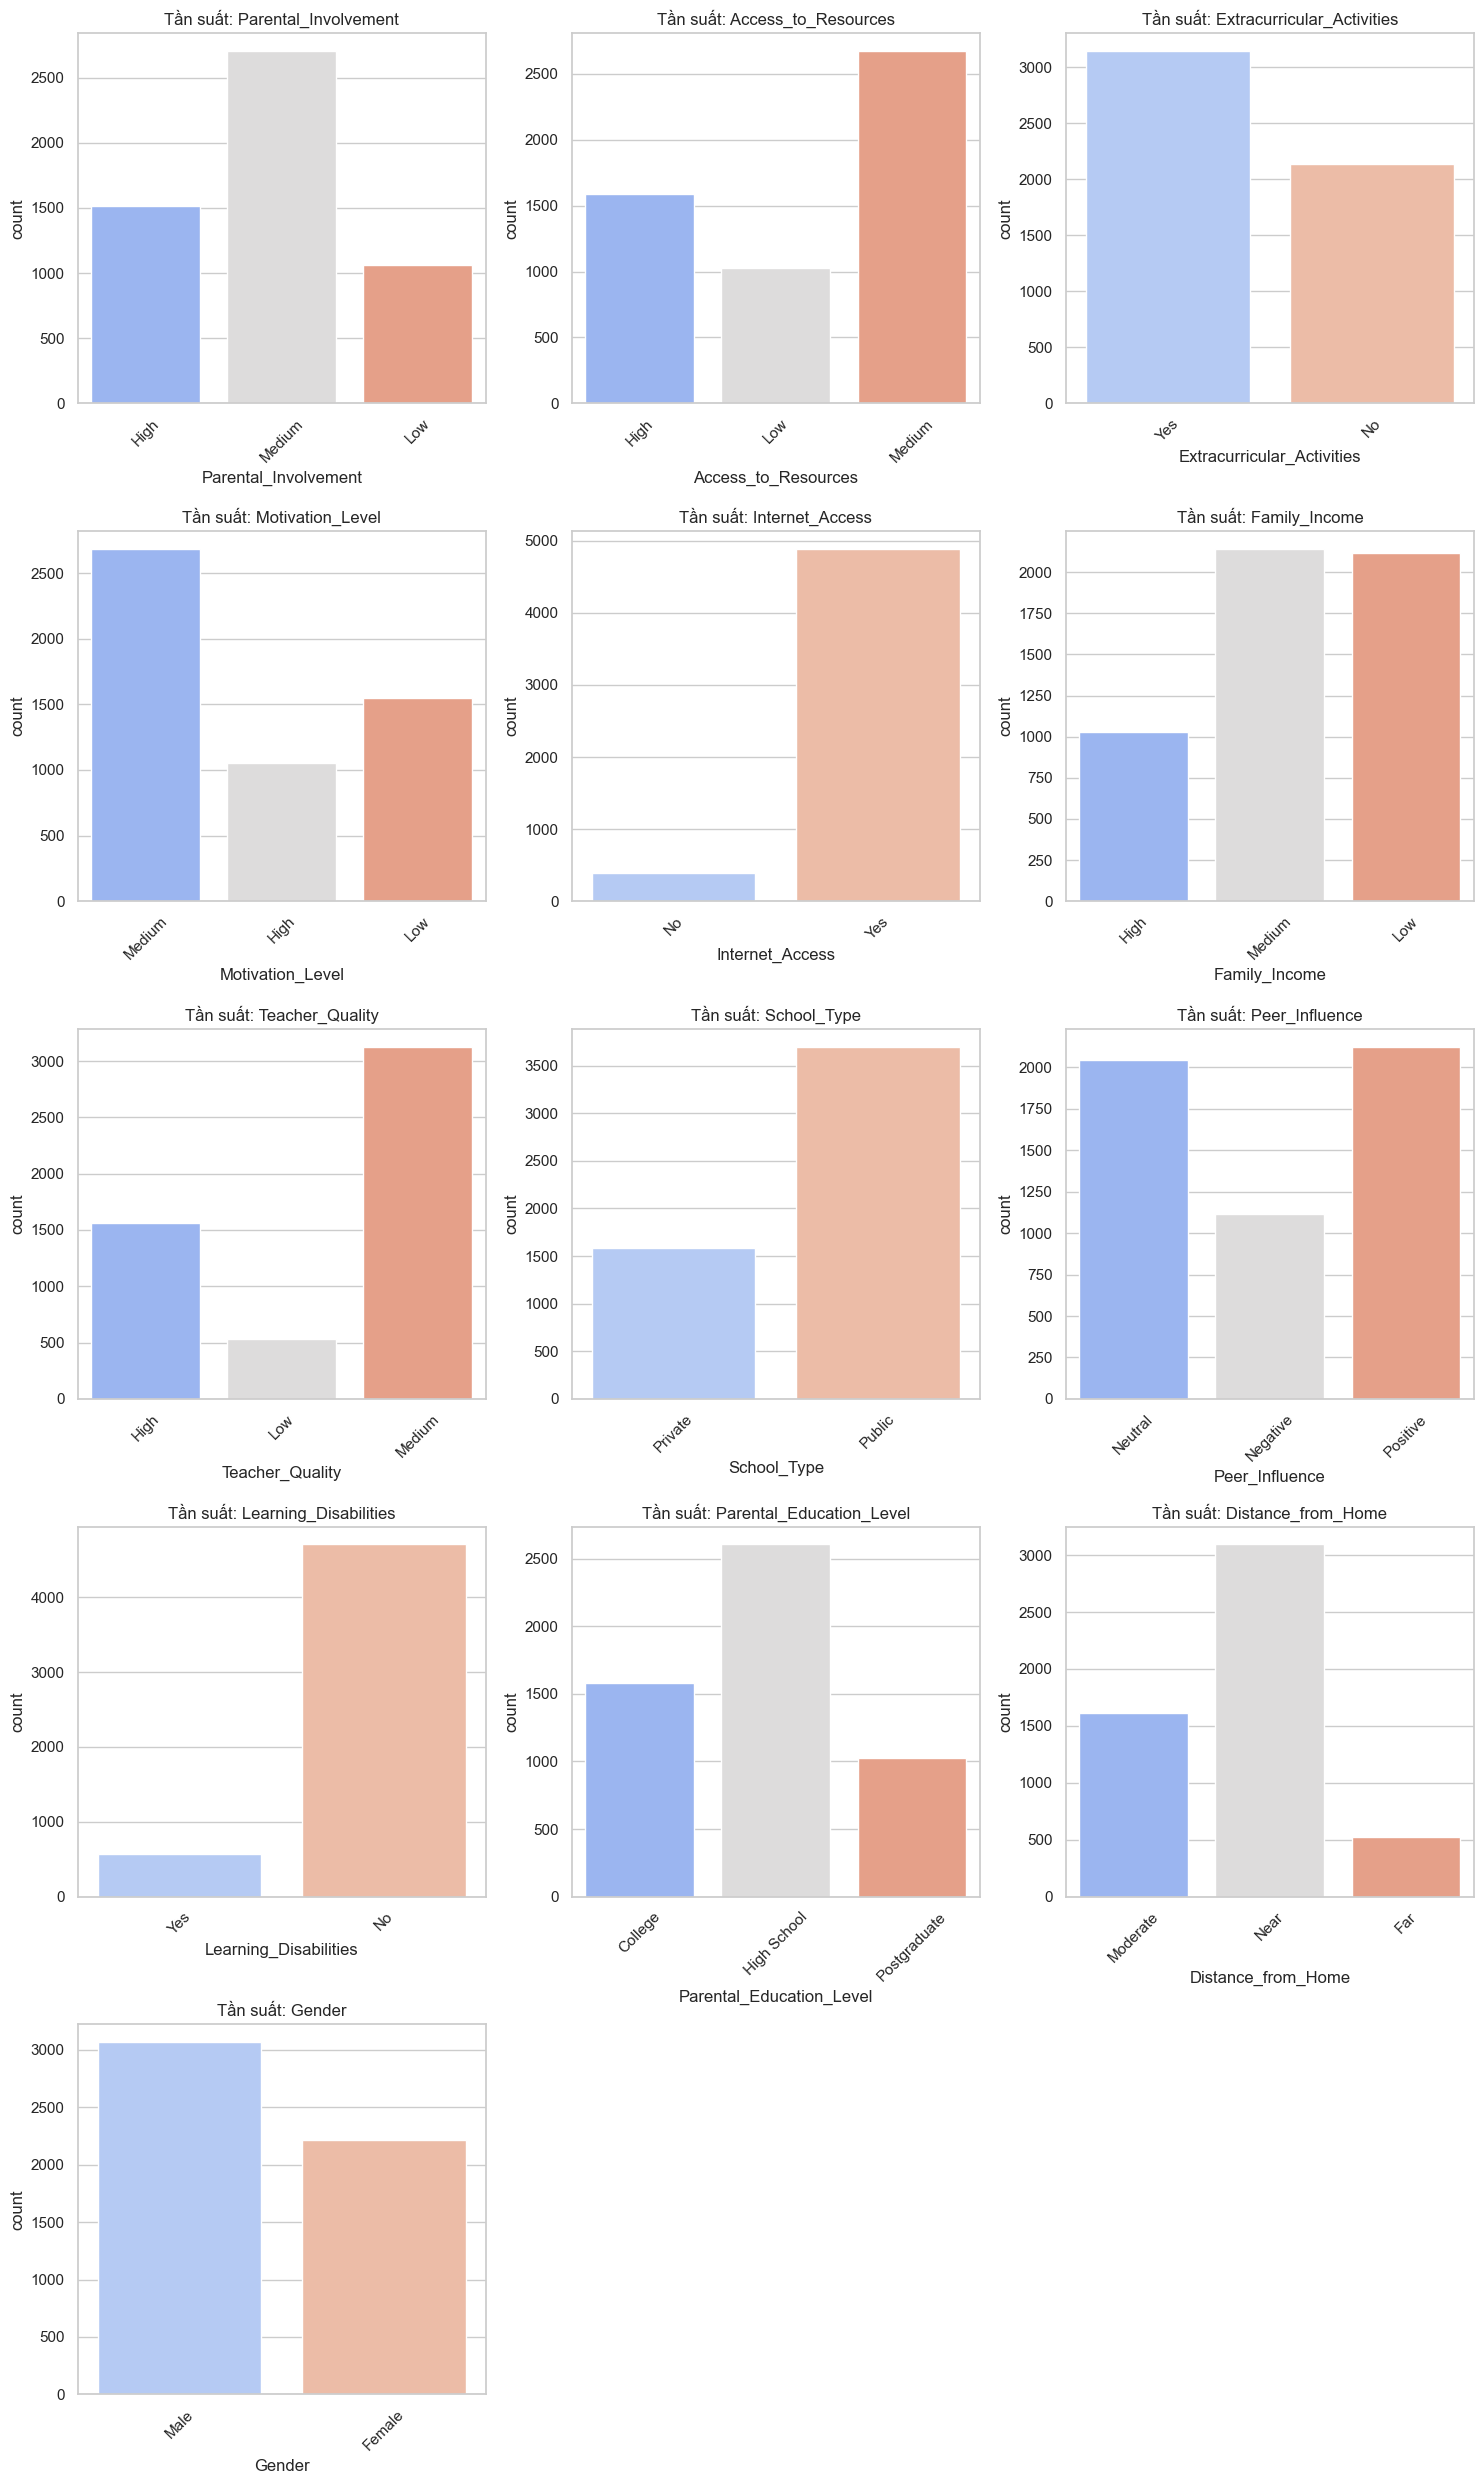

In [47]:
n = len(cat_features)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Vẽ biểu đồ
    sns.countplot(data=X_train_analysis, x=col, ax=axes[i], palette='coolwarm', hue=col)
    
    # Ẩn legend thừa trên từng ô
    if axes[i].get_legend():
        axes[i].get_legend().remove()
        
    axes[i].set_title(f"Tần suất: {col}")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

# Xóa các ô trống
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Numeric Outlier Scan
Boxplots dùng để scan outlier nhanh cho numeric features. Phase này không tự động xóa outlier vì chưa có rule chứng minh chúng invalid. Median imputation và regularized linear model là lựa chọn an toàn hơn cho baseline.


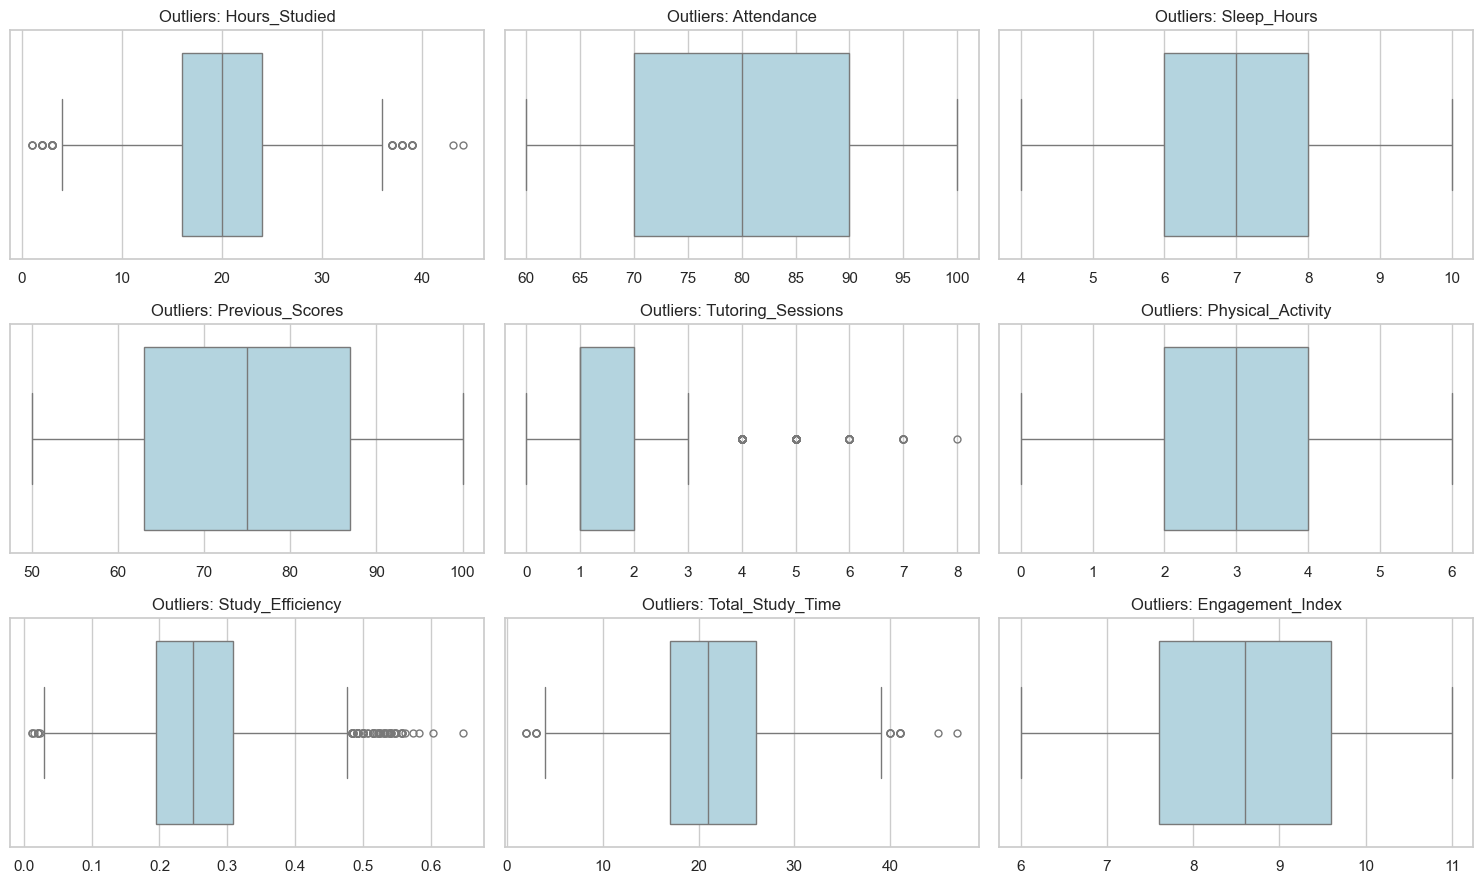

In [48]:
# Dùng num_features (đã loại bỏ Exam_Score)
n = len(num_features)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # Vẽ Boxplot nằm ngang
    sns.boxplot(data=X_train_analysis, x=col, ax=axes[i], color='lightblue', fliersize=5)
    axes[i].set_title(f'Outliers: {col}')
    axes[i].set_xlabel("")

# Xóa các ô thừa
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Numeric Relationships with Target
LOWESS/regression plots kiểm tra quan hệ numeric feature với Exam_Score có gần tuyến tính hay không. Điều này hỗ trợ Ridge baseline và cho thấy khi nào nonlinear model có thể đáng thử. Plot chỉ là exploratory, không dùng để tune theo test set.


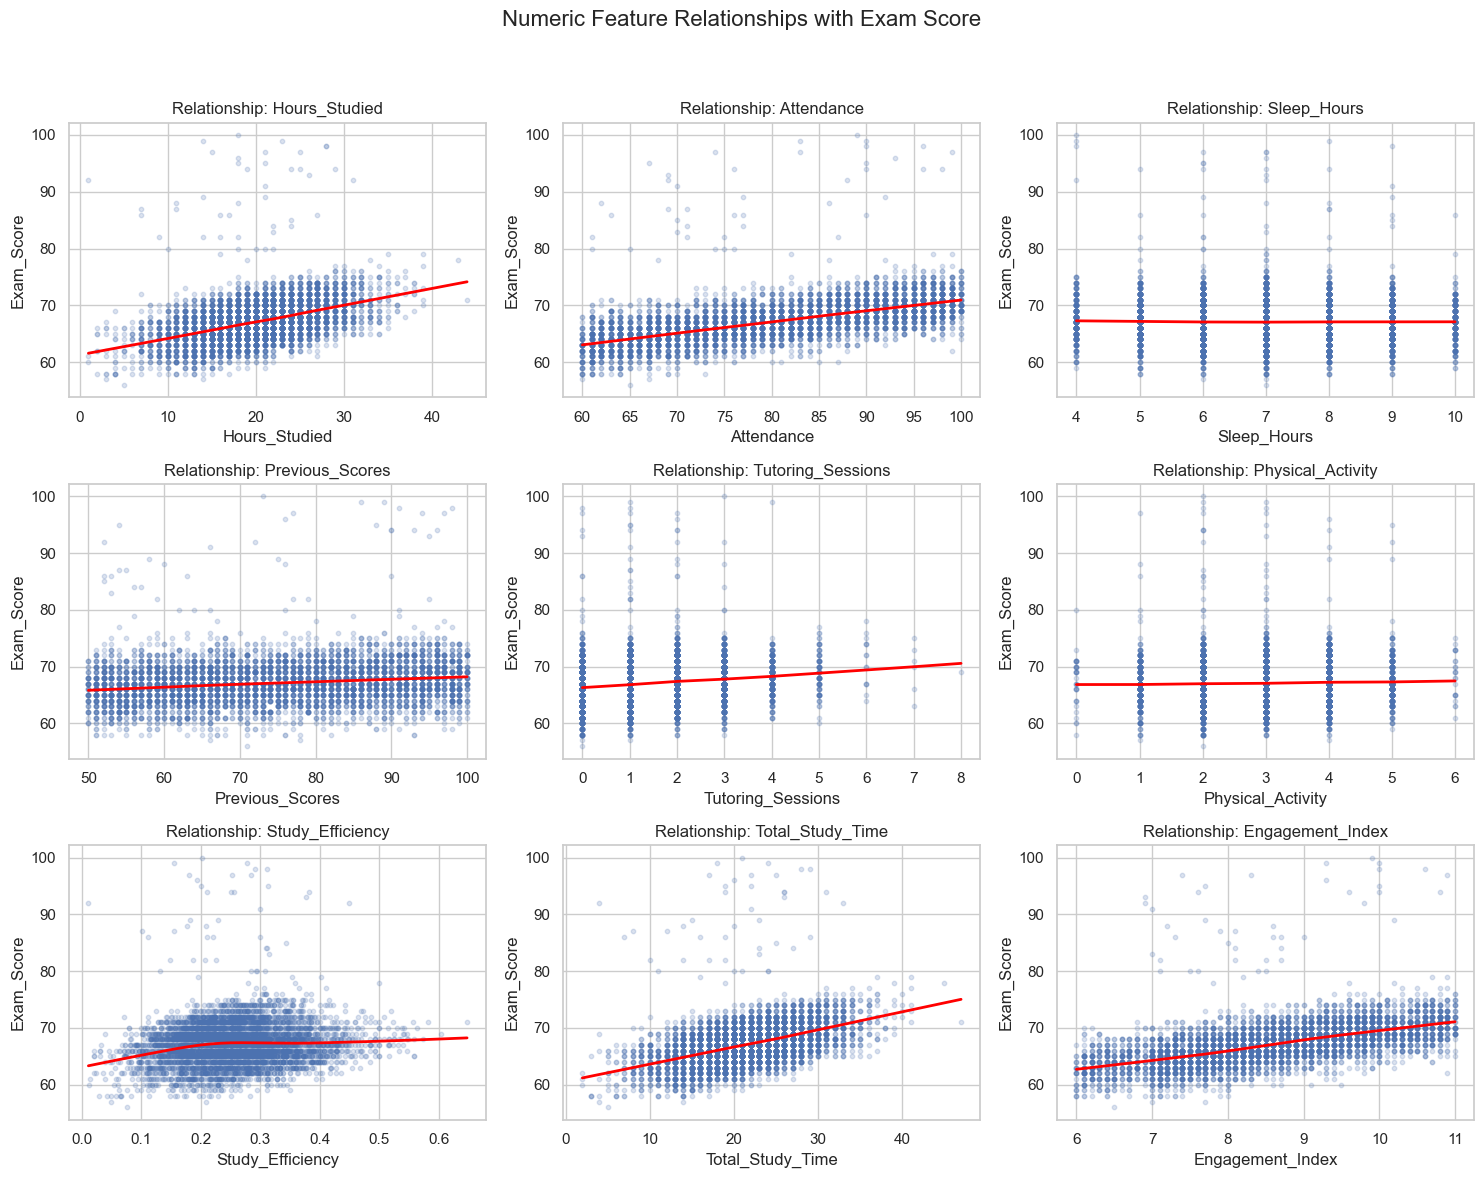

In [49]:
plot_df = pd.concat([X_train_analysis, y_train], axis=1)
n_cols = 3
n_rows = math.ceil(len(num_features) / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(num_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.regplot(
        x=col,
        y="Exam_Score",
        data=plot_df,
        lowess=True,
        scatter_kws={"alpha": 0.2, "s": 10},
        line_kws={"color": "red", "lw": 2},
    )
    plt.title(f"Relationship: {col}")
    plt.xlabel(col)
    plt.ylabel("Exam_Score")

plt.suptitle("Numeric Feature Relationships with Exam Score", fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Numeric Correlation
Correlation heatmap làm rõ quan hệ tuyến tính giữa numeric features và target. Nó hữu ích để phát hiện predictors dư thừa trước khi dùng linear model. Correlation không thay thế feature selection vì có thể bỏ lỡ nonlinear hoặc categorical effects.


<Figure size 1000x600 with 0 Axes>

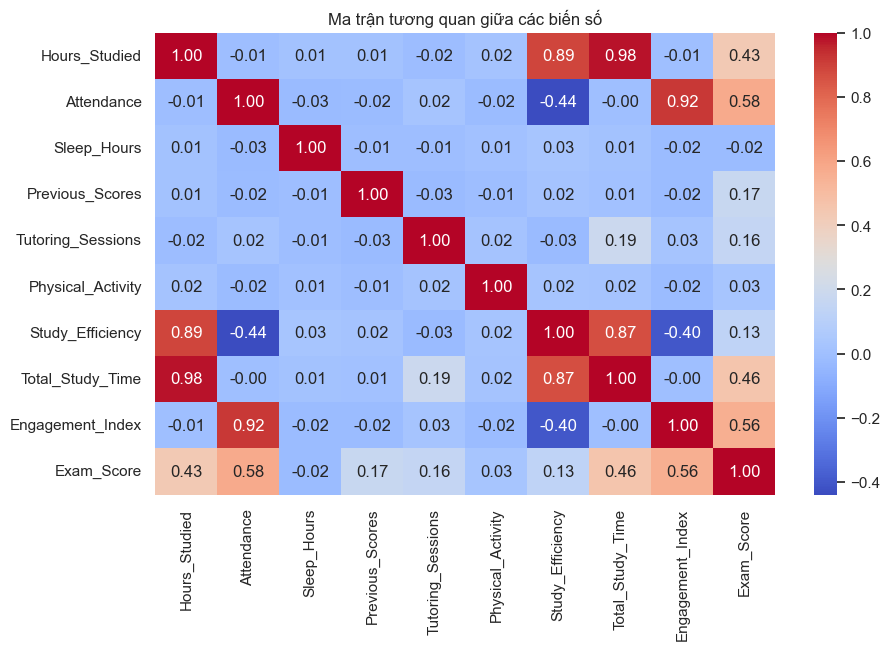

In [50]:
# Thiết lập kích thước vàng (ví dụ 10 inch x 6 inch)
temp_df = pd.concat([X_train_analysis, y_train], axis=1)

plt.figure(figsize=(10, 6), dpi=100) # 1000x600 pixels
corr = temp_df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến số')
plt.show()


## Mutual Information
Mutual Information là signal phi tuyến cho feature relevance và chỉ được fit trên train set. Temporary ordinal encoding ở đây chỉ phục vụ diagnostics, không phải final preprocessing representation. MI có thể noisy nên được kết hợp với p-value và correlation filtering.


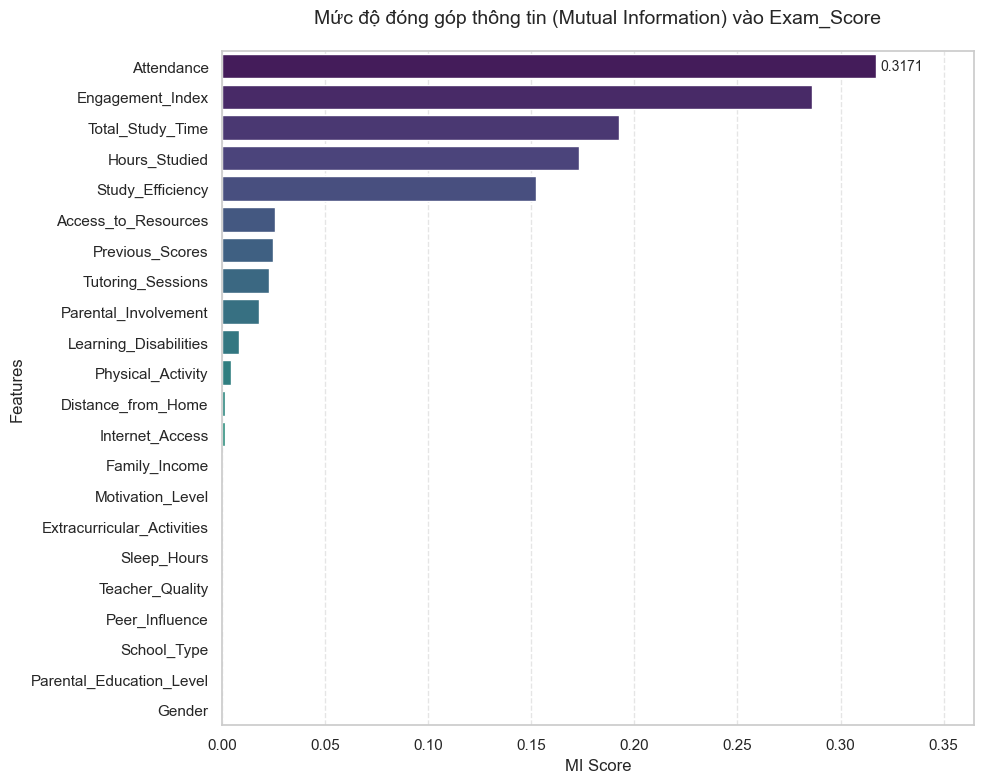

In [51]:
# =================================================================
# PHẦN: TÍNH TOÁN MUTUAL INFORMATION (LỌC BIẾN PHI TUYẾN)

# 1. Tạo bản sao dữ liệu Train để tính toán (Chống Data Leakage)
# Chúng ta không thao tác trực tiếp trên X_train để giữ dữ liệu sạch cho Pipeline
X_mi = X_train_analysis.copy()
y_mi = y_train.copy()

# 2. Xử lý giá trị thiếu (Imputation) cho các biến phân loại
# MI không chấp nhận giá trị NaN, nên ta điền tạm thời bằng chuỗi 'Missing'
X_mi[cat_features] = X_mi[cat_features].fillna('Missing')

# 3. Mã hóa TẠM THỜI (Temporary Encoding) cho toàn bộ biến chữ
# Lưu ý: Ở bước MI, dùng OrdinalEncoder cho cả Nominal và Binary là ĐÚNG.
# Vì MI chỉ cần phân biệt các nhóm (unique values), không quan tâm đến thứ tự hay khoảng cách.
temp_label_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_mi[cat_features] = temp_label_encoder.fit_transform(X_mi[cat_features].astype(str))

# 4. Tạo "Mặt nạ" (Discrete Mask) để báo cho hàm MI biết cột nào là biến phân loại
# Điều này cực kỳ quan trọng để hàm MI tính toán chính xác theo phân phối rời rạc
discrete_mask = [col in cat_features for col in X_mi.columns]

# 5. Tính toán điểm Mutual Information (MI Score)
# random_state=42 giúp kết quả nhất quán mỗi khi chạy lại
mi_scores = mutual_info_regression(
    X_mi, y_mi, 
    discrete_features=discrete_mask, 
    random_state=42
)

# 6. Đóng gói kết quả vào DataFrame và sắp xếp từ cao đến thấp
mi_df = pd.DataFrame({
    'Feature': X_mi.columns, 
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# 7. Trực quan hóa kết quả bằng biểu đồ Barplot
plt.figure(figsize=(10, 8))

# 1. Vẽ biểu đồ và gán vào biến ax để thao tác trên các cột
ax = sns.barplot(data=mi_df, x='MI_Score', y='Feature', palette='viridis')

# 2. Thêm số vào đầu mỗi cột (Data Annotation)
# padding=3 để đẩy chữ ra xa cột một chút
# fmt='%.4f' để lấy 4 chữ số thập phân (vì MI Score thường khá nhỏ)
ax.bar_label(ax.containers[0], padding=3, fmt='%.4f', fontsize=10)

# 3. Trang trí thêm
plt.title('Mức độ đóng góp thông tin (Mutual Information) vào Exam_Score', fontsize=14, pad=20)
plt.xlabel('MI Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Nới rộng trục x một chút để con số không bị dính vào mép biểu đồ
plt.xlim(0, mi_df['MI_Score'].max() * 1.15) 

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## ANOVA for Categorical Features
ANOVA kiểm tra target mean có khác biệt giữa các nhóm category hay không. Kết quả giúp xác định categorical predictors đáng giữ sau encoding. P-value ở đây là screening signal, không phải bằng chứng nhân quả.


⏳ Đang tiến hành kiểm định ANOVA...


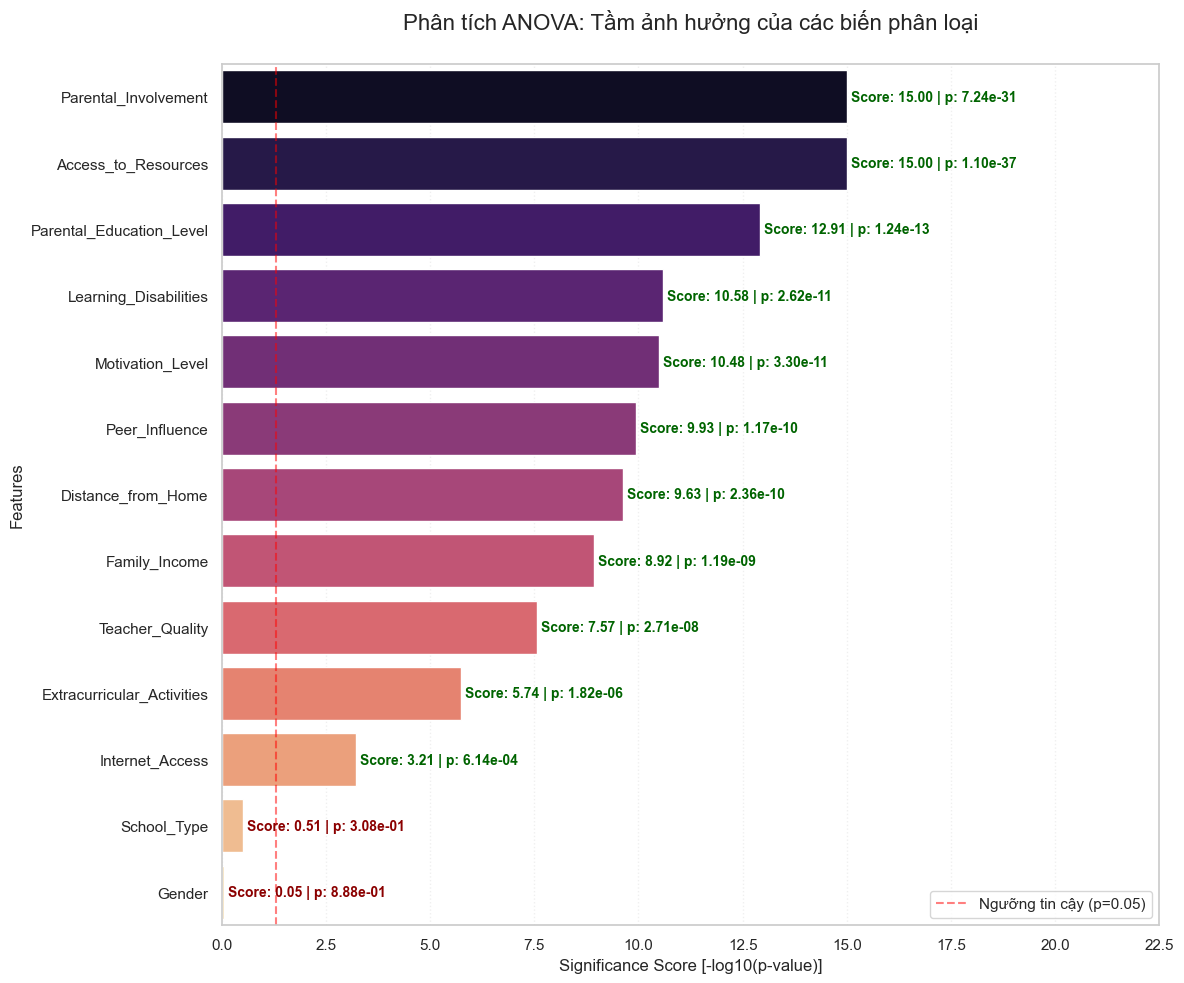

✅ Đã hoàn thành phân tích ANOVA.


In [52]:
# =================================================================
# PHẦN: KIỂM ĐỊNH ANOVA (PHÂN TÍCH Ý NGHĨA BIẾN PHÂN LOẠI)
# =================================================================

# 1. Chuẩn bị dữ liệu từ tập TRAIN để đảm bảo tính khách quan (Chống Leakage)
temp_df = pd.concat([X_train_analysis, y_train], axis=1)
target_col = 'Exam_Score'
anova_list = []

print("⏳ Đang tiến hành kiểm định ANOVA...")

for col in cat_features:
    # 2. Gom nhóm và Lọc sạch mẫu nhỏ (Tránh SmallSampleWarning)
    # Một nhóm phải có ít nhất 2 mẫu để tính được phương sai nội tại
    valid_groups = []
    for val in temp_df[col].unique():
        group = temp_df[temp_df[col] == val][target_col].dropna()
        if len(group) > 1:
            valid_groups.append(group)
    
    # 3. Thực hiện kiểm định f_oneway nếu có ít nhất 2 nhóm để so sánh
    if len(valid_groups) >= 2:
        try:
            stat, p = f_oneway(*valid_groups)
            
            # Xử lý p-value cực nhỏ để tránh lỗi toán học khi tính Log10
            # Ngưỡng 1e-15 là đủ nhỏ để thể hiện sự khác biệt cực lớn
            p_safe = max(p, 1e-15) if not np.isnan(p) else np.nan
            
            anova_list.append({
                'Feature': col, 
                'p_value': p, 
                'Significance_Score': -np.log10(p_safe)
            })
        except Exception:
            continue

# 4. Đóng gói vào DataFrame và sắp xếp theo độ quan trọng
anova_df = pd.DataFrame(anova_list).dropna()
anova_df = anova_df.sort_values('Significance_Score', ascending=False)

# 5. Trực quan hóa kết quả
plt.figure(figsize=(12, 10)) 
ax = sns.barplot(
    data=anova_df, 
    x='Significance_Score', 
    y='Feature', 
    palette='magma'
)

# 6. Ghi số liệu (Score & p-value) trực tiếp lên biểu đồ
for i, (score, p) in enumerate(zip(anova_df['Significance_Score'], anova_df['p_value'])):
    text_color = 'darkgreen' if p <= 0.05 else 'darkred'
    # Hiển thị cả Score và p-value dạng số mũ
    display_text = f'Score: {score:.2f} | p: {p:.2e}'
    
    ax.text(
        score + 0.1, i, 
        display_text, 
        va='center', 
        fontsize=10, 
        fontweight='bold',
        color=text_color
    )

# 7. TRANG TRÍ VÀ HIỂN THỊ (Gộp tất cả vào đây)
# Đường giới hạn p = 0.05
plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='Ngưỡng tin cậy (p=0.05)')

plt.title('Phân tích ANOVA: Tầm ảnh hưởng của các biến phân loại', fontsize=16, pad=25)
plt.xlabel('Significance Score [-log10(p-value)]', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Nới rộng trục X 1.5 lần để không mất chữ
plt.xlim(0, anova_df['Significance_Score'].max() * 1.5) 

plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.3)
plt.tight_layout()

# Lệnh hiển thị cuối cùng
plt.show()

print("✅ Đã hoàn thành phân tích ANOVA.")


## Ordinal Monotonicity Check
Các plot này kiểm tra category được encode theo thứ bậc có đi theo xu hướng hợp lý với target không. Nếu thứ tự không monotonic, ordinal encoding có thể đưa vào giả định sai. Đây là evidence để review preprocessing, không phải hard guarantee.


🔍 Đang kiểm tra tính đơn điệu của các biến Ordinal...


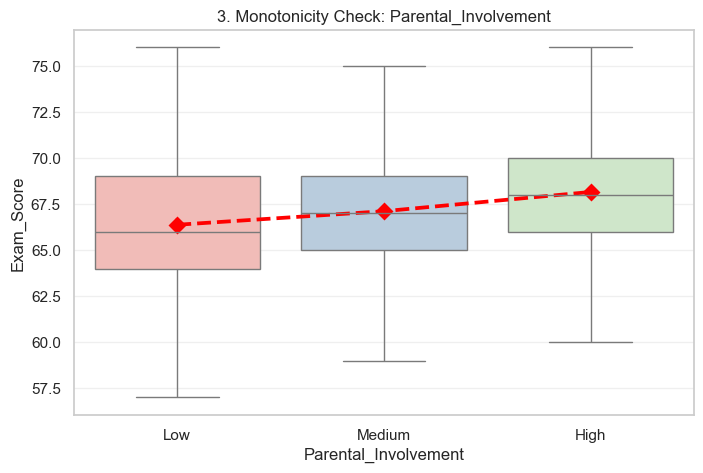

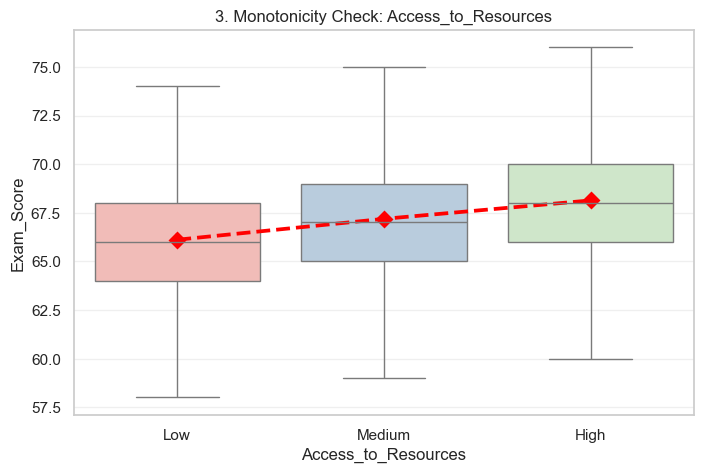

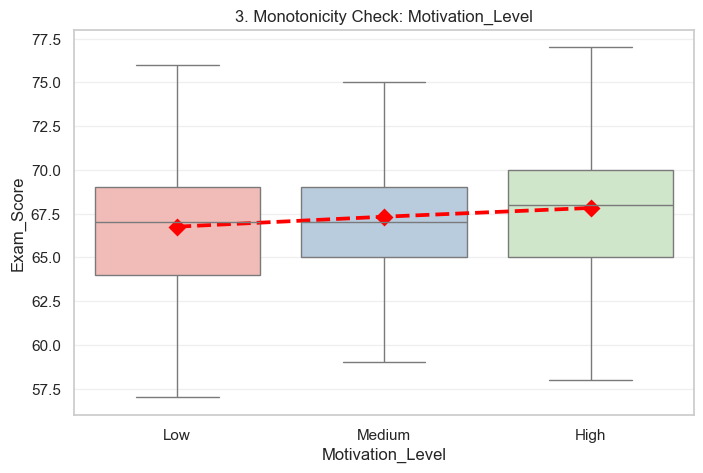

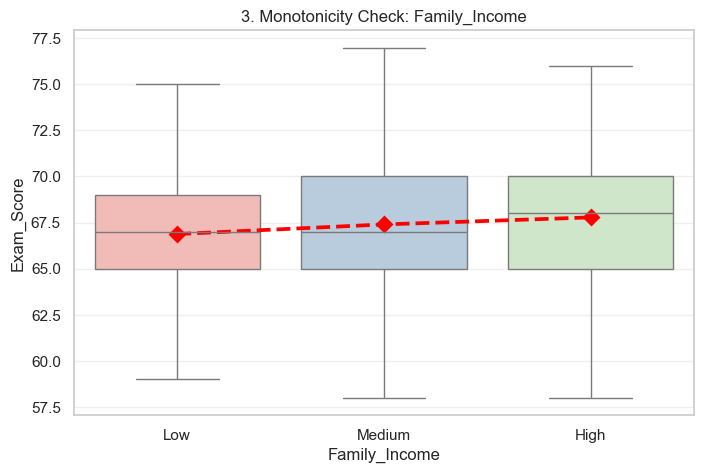

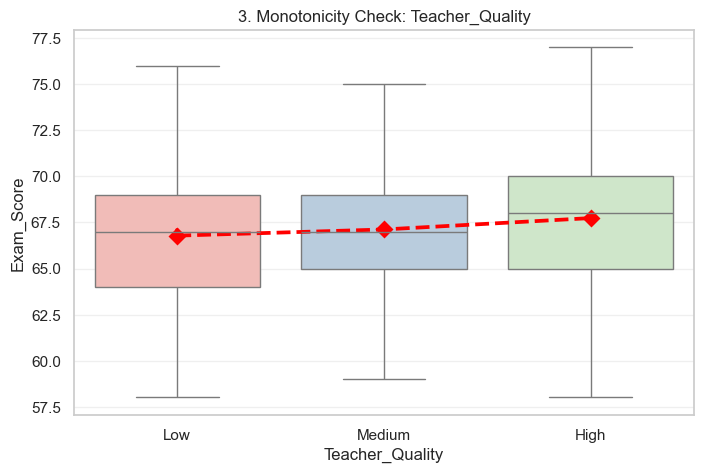

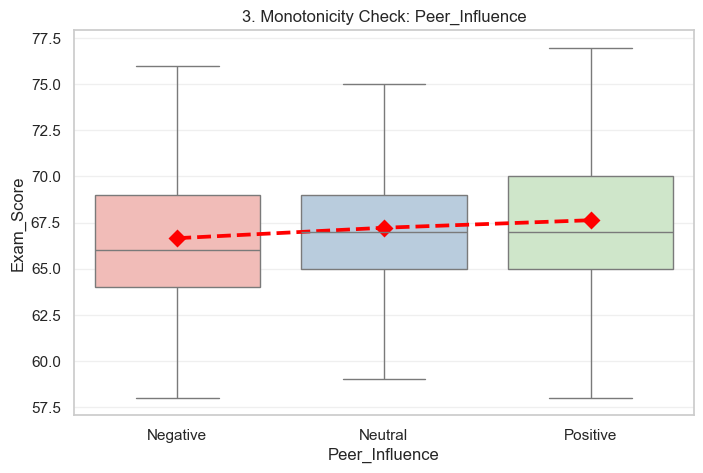

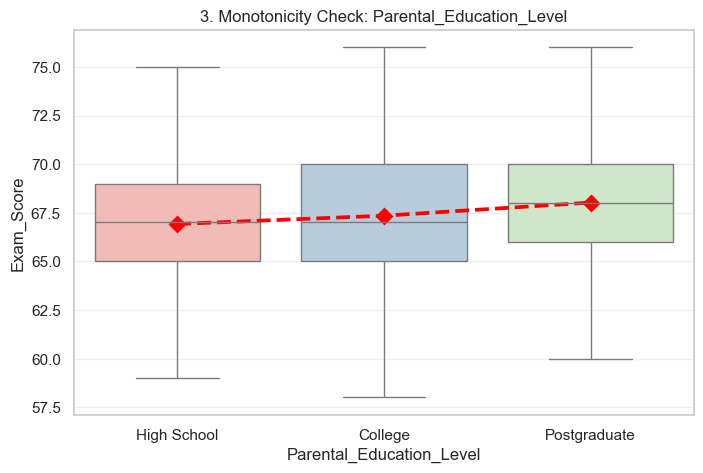

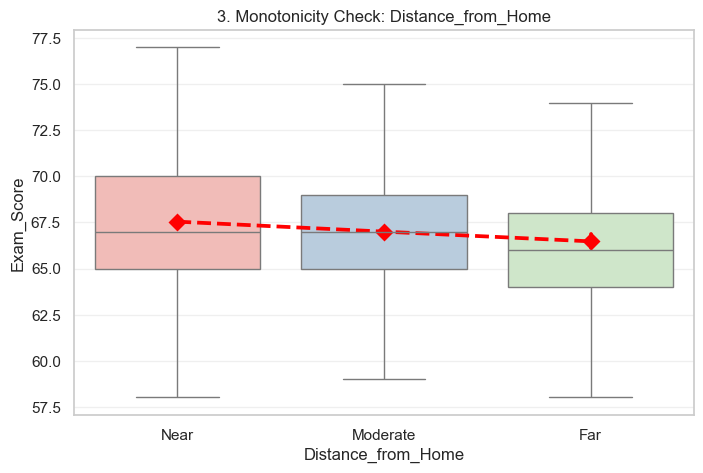

In [53]:
# BƯỚC 4: ORDINAL MONOTONICITY (KIỂM TRA TÍNH LOGIC THỨ BẬC)
ordinal_mapping = {
    'Parental_Involvement': ['Low', 'Medium', 'High'],
    'Access_to_Resources': ['Low', 'Medium', 'High'],
    'Motivation_Level': ['Low', 'Medium', 'High'],
    'Family_Income': ['Low', 'Medium', 'High'],
    'Teacher_Quality': ['Low', 'Medium', 'High'],
    'Peer_Influence': ['Negative', 'Neutral', 'Positive'],
    'Parental_Education_Level': ['High School', 'College', 'Postgraduate'],
    'Distance_from_Home': ['Near', 'Moderate', 'Far']
}
# =================================================================
print("🔍 Đang kiểm tra tính đơn điệu của các biến Ordinal...")
for col, order in ordinal_mapping.items():
    if col in temp_df.columns:
        plt.figure(figsize=(8, 5))
        # Vẽ Boxplot kết hợp Pointplot để thấy đường xu hướng (Trend line)
        sns.boxplot(data=temp_df, x=col, y=target_col, order=order, palette='Pastel1', showfliers=False)
        sns.pointplot(data=temp_df, x=col, y=target_col, order=order, color='red', markers='D', linestyles='--')
        
        plt.title(f'3. Monotonicity Check: {col}', fontsize=12)
        plt.grid(axis='y', alpha=0.3)
        plt.show()


## Interaction Checks
Một số interaction plots nhỏ được giữ để xem predictor mạnh có thay đổi theo categorical groups hay không. Không mở rộng quá nhiều chart để tránh EDA bloat. Phase 1 chưa thêm interaction features mới.


👉 Đang phân tích: Parental_Involvement & Access_to_Resources


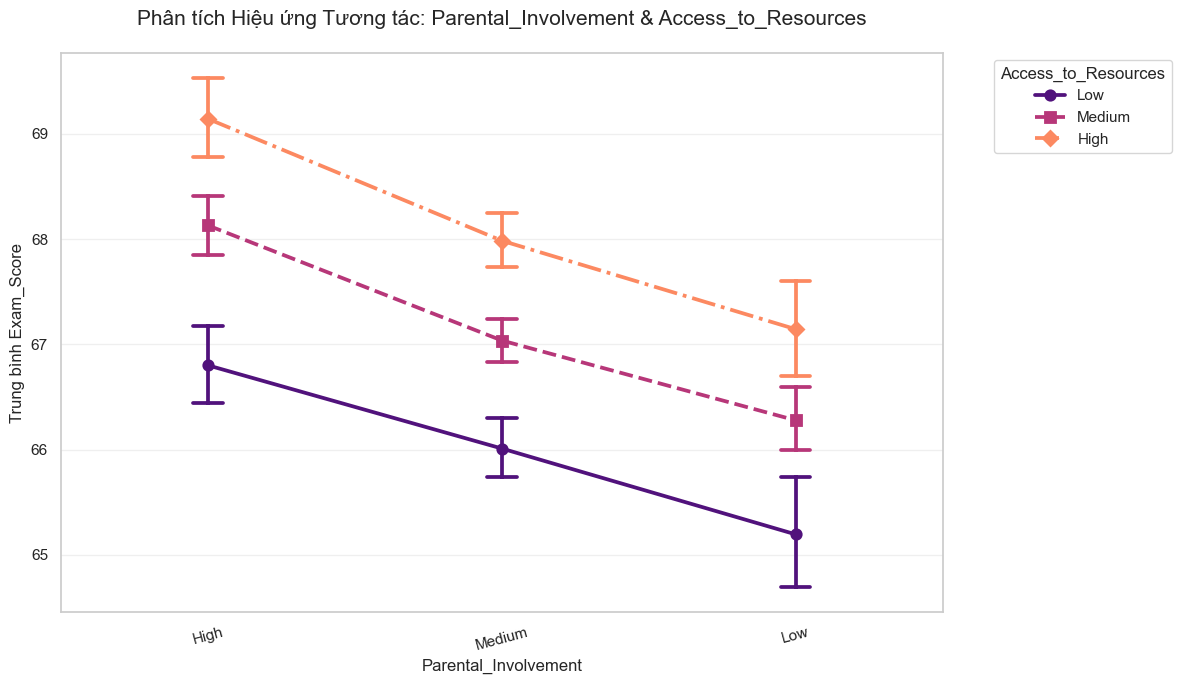

👉 Đang phân tích: Hours_Studied & Motivation_Level


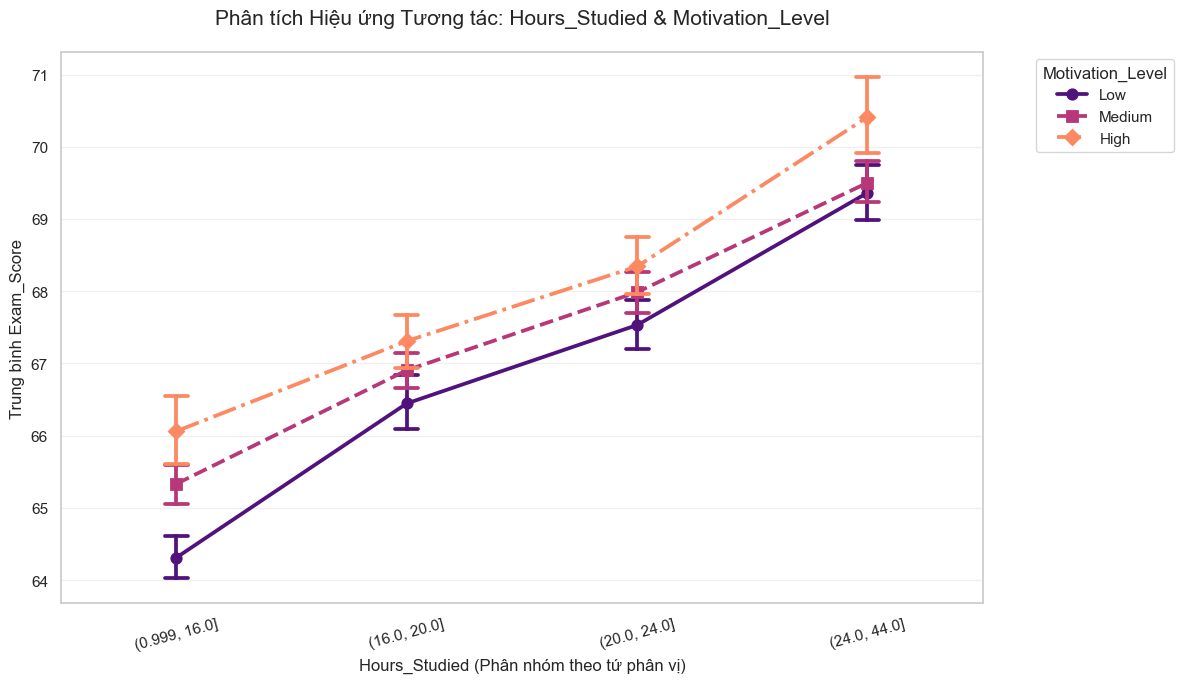

👉 Đang phân tích: Attendance & Access_to_Resources


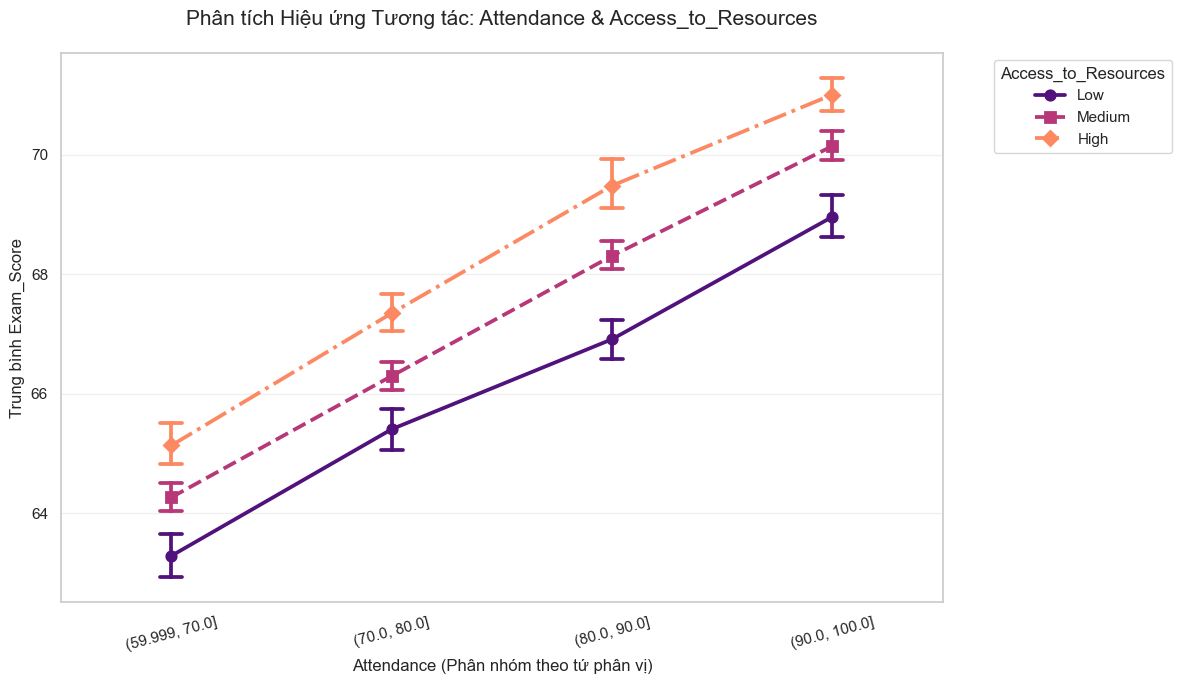

In [54]:
# 1. Chuẩn bị dữ liệu
temp_df = pd.concat([X_train_analysis, y_train], axis=1)

def plot_interaction_pro(df, feat1, feat2, target, order1=None, hue_order=None):
    plt.figure(figsize=(12, 7))
    df_plot = df.copy()
    
    # --- XỬ LÝ TRỤC X (FEAT1) ---
    if pd.api.types.is_numeric_dtype(df_plot[feat1]):
        # Chỉ khi là số mới chia bin
        df_plot[feat1] = pd.qcut(df_plot[feat1], q=4, duplicates='drop')
        x_order = sorted(df_plot[feat1].unique())
        xlabel = f"{feat1} (Phân nhóm theo tứ phân vị)"
    else:
        # Nếu là chữ (Parental_Involvement) thì cứ để nguyên để vẽ
        x_order = None # Hoặc định nghĩa thứ tự cụ thể ['Low', 'Medium', 'High']
        xlabel = feat1

    # --- VẼ BIỂU ĐỒ ---
    sns.pointplot(
        data=df_plot, 
        x=feat1, 
        y=target, 
        hue=feat2,
        order=x_order, 
        hue_order=hue_order,
        palette='magma', 
        capsize=.1, 
        markers=["o", "s", "D"],
        linestyles=["-", "--", "-."]
    )

    # --- TRANG TRÍ ---
    plt.title(f'Phân tích Hiệu ứng Tương tác: {feat1} & {feat2}', fontsize=15, pad=20)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(f'Trung bình {target}', fontsize=12)
    plt.legend(title=feat2, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# =================================================================
# GỌI HÀM KIỂM TRA (Đúng tham số)
# =================================================================

# Cặp 1: Hai biến phân loại mạnh nhất
print("👉 Đang phân tích: Parental_Involvement & Access_to_Resources")
plot_interaction_pro(
    temp_df, 
    feat1='Parental_Involvement', 
    feat2='Access_to_Resources', 
    target='Exam_Score',
    order1=['Low', 'Medium', 'High'],
    hue_order=['Low', 'Medium', 'High']
)

# Cặp 2: Biến số mạnh và Biến phân loại
print("👉 Đang phân tích: Hours_Studied & Motivation_Level")
plot_interaction_pro(
    temp_df, 
    feat1='Hours_Studied', 
    feat2='Motivation_Level', 
    target='Exam_Score',
    hue_order=['Low', 'Medium', 'High']
)

# Cặp 3: Biến số mạnh nhất và Tài nguyên
print("👉 Đang phân tích: Attendance & Access_to_Resources")
plot_interaction_pro(
    temp_df, 
    feat1='Attendance', 
    feat2='Access_to_Resources', 
    target='Exam_Score',
    hue_order=['Low', 'Medium', 'High']
)


# 5. Preprocessing and Feature Selection
Phase 1 giữ nguyên hybrid feature-selection approach hiện có. Diagnostics được fit trên train split, sau đó map về raw feature names để final pipeline vẫn nhận raw input giống app.


In [55]:
current_num = [c for c in full_num_features if c in X_train_analysis.columns]
current_bin = [c for c in bin_features_master if c in X_train_analysis.columns]

current_ord = []
current_ord_categories = []
for i, col in enumerate(ord_features_master):
    if col in X_train_analysis.columns:
        current_ord.append(col)
        current_ord_categories.append(ord_categories_master[i])

if len(current_num) + len(current_bin) + len(current_ord) == 0:
    raise ValueError("No feature groups matched the training data.")

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            current_num,
        ),
        (
            "ord",
            Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                ("enc", OrdinalEncoder(categories=current_ord_categories)),
            ]),
            current_ord,
        ),
        (
            "bin",
            Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                ("enc", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")),
            ]),
            current_bin,
        ),
    ],
    remainder="drop",
)

print(
    "Preprocessor groups: "
    f"{len(current_num)} numeric, {len(current_ord)} ordinal, {len(current_bin)} binary/nominal."
)


Preprocessor groups: 9 numeric, 8 ordinal, 5 binary/nominal.


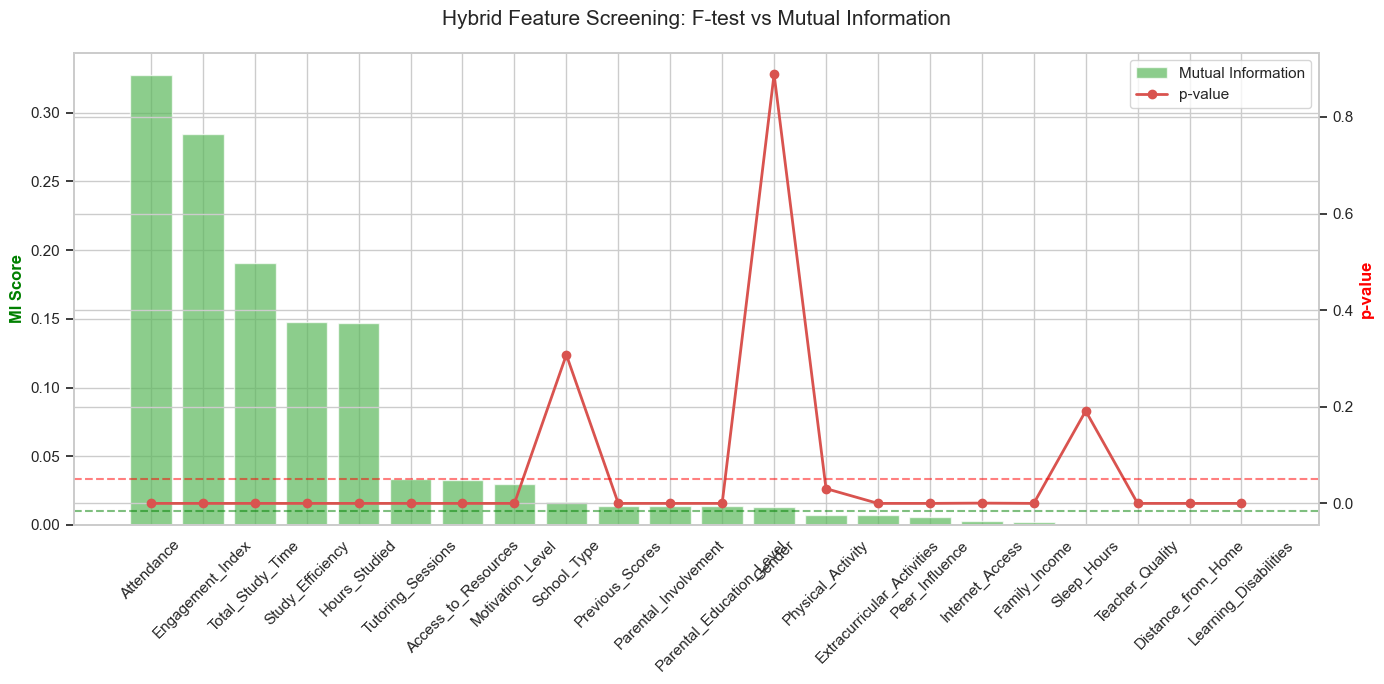

Selected encoded features before correlation filter: 21
Dropped highly correlated features: 3
Final selected encoded features: 18
['Attendance', 'Total_Study_Time', 'Tutoring_Sessions', 'Access_to_Resources', 'Motivation_Level', 'School_Type', 'Previous_Scores', 'Parental_Involvement', 'Parental_Education_Level', 'Gender', 'Physical_Activity', 'Extracurricular_Activities', 'Peer_Influence', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'Distance_from_Home', 'Learning_Disabilities']


In [56]:
X_train_encoded = preprocessor.fit_transform(X_train_analysis)
X_test_encoded = preprocessor.transform(X_test_analysis)

_, p_values = f_regression(X_train_encoded, y_train)
mi_scores = mutual_info_regression(X_train_encoded, y_train, random_state=42)

selection_df = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "p_value": p_values,
    "MI_Score": mi_scores,
})


def clean_feature_names(name):
    clean_name = name.split("__")[-1]
    suffixes = [
        "_Yes",
        "_No",
        "_Male",
        "_Female",
        "_Public",
        "_Private",
        "_Urban",
        "_Rural",
    ]
    for suffix in suffixes:
        if clean_name.endswith(suffix):
            clean_name = clean_name.replace(suffix, "")
    return clean_name


selection_df["Clean_Feature"] = selection_df["Feature"].apply(clean_feature_names)
selection_df = selection_df.sort_values(by="MI_Score", ascending=False).reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

ax1.bar(
    selection_df["Clean_Feature"],
    selection_df["MI_Score"],
    color="#5cb85c",
    alpha=0.7,
    label="Mutual Information",
)
ax2.plot(
    selection_df["Clean_Feature"],
    selection_df["p_value"],
    color="#d9534f",
    marker="o",
    linewidth=2,
    label="p-value",
)

ax1.axhline(y=0.01, color="green", linestyle="--", alpha=0.5)
ax2.axhline(y=0.05, color="red", linestyle="--", alpha=0.5)
ax1.tick_params(axis="x", labelrotation=45)

ax1.set_ylabel("MI Score", fontsize=12, fontweight="bold", color="green")
ax2.set_ylabel("p-value", fontsize=12, fontweight="bold", color="red")
plt.title("Hybrid Feature Screening: F-test vs Mutual Information", fontsize=15, pad=20)

lns1, labs1 = ax1.get_legend_handles_labels()
lns2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, labs1 + labs2, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

selected_mask = (selection_df["p_value"] < 0.05) | (selection_df["MI_Score"] > 0.01)
selected_df = selection_df[selected_mask].copy()
encoded_selected_features = selected_df["Feature"].tolist()

X_train_selected = X_train_encoded[encoded_selected_features].copy()
X_test_selected = X_test_encoded[encoded_selected_features].copy()

corr_matrix = X_train_selected.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.85
features_to_drop = []

for col in upper_triangle.columns:
    high_corr_features = upper_triangle.index[upper_triangle[col] > corr_threshold].tolist()
    for row_feature in high_corr_features:
        row_info = selected_df[selected_df["Feature"] == row_feature]
        col_info = selected_df[selected_df["Feature"] == col]
        if row_info.empty or col_info.empty:
            continue

        row_mi = row_info["MI_Score"].values[0]
        col_mi = col_info["MI_Score"].values[0]
        row_p = row_info["p_value"].values[0]
        col_p = col_info["p_value"].values[0]

        if row_mi > col_mi:
            drop_feature = col
        elif row_mi < col_mi:
            drop_feature = row_feature
        else:
            drop_feature = col if row_p > col_p else row_feature

        if drop_feature not in features_to_drop:
            features_to_drop.append(drop_feature)

X_train_clean = X_train_selected.drop(columns=features_to_drop, errors="ignore")
X_test_clean = X_test_selected.drop(columns=features_to_drop, errors="ignore")

display_feature_names = [clean_feature_names(col) for col in X_train_clean.columns]

print(f"Selected encoded features before correlation filter: {len(encoded_selected_features)}")
print(f"Dropped highly correlated features: {len(features_to_drop)}")
print(f"Final selected encoded features: {X_train_clean.shape[1]}")
print(display_feature_names)


In [57]:
def encoded_to_raw_feature(feature_name):
    raw_name = feature_name.split("__")[-1]
    known_suffixes = [
        "_Yes",
        "_No",
        "_Male",
        "_Female",
        "_Public",
        "_Private",
        "_Urban",
        "_Rural",
    ]
    for suffix in known_suffixes:
        if raw_name.endswith(suffix):
            raw_name = raw_name.replace(suffix, "")
    return raw_name


encoded_survivors = X_train_clean.columns.tolist()
raw_survivors = [encoded_to_raw_feature(col) for col in encoded_survivors]
raw_survivors = list(dict.fromkeys(raw_survivors))

current_num = [c for c in full_num_features if c in raw_survivors]
current_bin = [c for c in bin_features_master if c in raw_survivors]

current_ord = []
current_ord_categories = []
for i, col in enumerate(ord_features_master):
    if col in raw_survivors:
        current_ord.append(col)
        current_ord_categories.append(ord_categories_master[i])

if len(current_num) + len(current_ord) + len(current_bin) == 0:
    raise ValueError("No raw features left after mapping encoded survivors to raw features.")

preprocessor_selected = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            current_num,
        ),
        (
            "ord",
            Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                ("enc", OrdinalEncoder(categories=current_ord_categories)),
            ]),
            current_ord,
        ),
        (
            "bin",
            Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                ("enc", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")),
            ]),
            current_bin,
        ),
    ],
    remainder="drop",
)

print(f"Raw survivors: {raw_survivors}")
print(
    "Selected preprocessor groups: "
    f"{len(current_num)} numeric, {len(current_ord)} ordinal, {len(current_bin)} binary/nominal."
)


Raw survivors: ['Attendance', 'Total_Study_Time', 'Tutoring_Sessions', 'Access_to_Resources', 'Motivation_Level', 'School_Type', 'Previous_Scores', 'Parental_Involvement', 'Parental_Education_Level', 'Gender', 'Physical_Activity', 'Extracurricular_Activities', 'Peer_Influence', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'Distance_from_Home', 'Learning_Disabilities']
Selected preprocessor groups: 5 numeric, 8 ordinal, 5 binary/nominal.


In [58]:
X_train_selected_encoded = preprocessor_selected.fit_transform(X_train_analysis[raw_survivors])
X_test_selected_encoded = preprocessor_selected.transform(X_test_analysis[raw_survivors])

print("✅ X_train_selected_encoded shape:", X_train_selected_encoded.shape)
print("✅ X_test_selected_encoded shape :", X_test_selected_encoded.shape)

print(X_train_selected_encoded.head())


✅ X_train_selected_encoded shape: (5284, 18)
✅ X_test_selected_encoded shape : (1322, 18)
      num__Attendance  num__Previous_Scores  num__Tutoring_Sessions  \
5937        -0.433104              0.136860               -0.398416   
4417        -0.606517              0.206483               -1.209679   
2949        -0.346398             -0.489743               -0.398416   
3086         0.347251             -0.072007               -0.398416   
5820        -1.560285              1.598934               -0.398416   

      num__Physical_Activity  num__Total_Study_Time  \
5937               -0.945182              -1.564396   
4417                0.025913              -2.223076   
2949                2.939199              -1.729066   
3086                0.025913              -0.082366   
5820                0.997008              -0.082366   

      ord__Parental_Involvement  ord__Access_to_Resources  \
5937                        3.0                       3.0   
4417                        2.

# 6. Multicollinearity Check
VIF là sanity check cho selected encoded features trước khi dùng linear models. VIF cao không bắt buộc phải xóa feature ngay, nhưng giúp giải thích vì sao Ridge phù hợp hơn plain Linear Regression.


In [59]:
def check_vif_optimized(X_df):
    X = X_df.select_dtypes(include=[np.number]).copy()
    constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
    X = X.drop(columns=constant_cols, errors="ignore")

    if X.shape[1] == 0:
        raise ValueError("No numeric columns left for VIF calculation.")

    X_with_const = add_constant(X)
    vif_data = pd.DataFrame({
        "Feature": X_with_const.columns,
        "VIF": [
            variance_inflation_factor(X_with_const.values, i)
            for i in range(X_with_const.shape[1])
        ],
    })

    vif_results = vif_data[vif_data["Feature"] != "const"].copy()
    vif_results["Display Name"] = vif_results["Feature"].apply(clean_feature_names)

    def get_status(vif):
        if vif < 5:
            return "Low"
        if vif < 10:
            return "Moderate"
        return "High"

    vif_results["Status"] = vif_results["VIF"].apply(get_status)
    return vif_results[["Feature", "Display Name", "VIF", "Status"]].sort_values(
        by="VIF",
        ascending=False,
    )


vif_report = check_vif_optimized(X_train_selected_encoded)
display(vif_report)

high_vif_count = (vif_report["VIF"] > 5).sum()
print(f"Features with VIF > 5: {high_vif_count}")


,Feature,Display Name,VIF,Status
3,num__Tutoring_Sessions,Tutoring_Sessions,1.038662,Low
5,num__Total_Study_Time,Total_Study_Time,1.037494,Low
1,num__Attendance,Attendance,1.004375,Low
6,ord__Parental_Involvement,Parental_Involvement,1.004174,Low
2,num__Previous_Scores,Previous_Scores,1.003987,Low
4,num__Physical_Activity,Physical_Activity,1.003689,Low
16,bin__Learning_Disabilities_Yes,Learning_Disabilities,1.003040,Low
7,ord__Access_to_Resources,Access_to_Resources,1.002631,Low
18,bin__School_Type_Public,School_Type,1.002418,Low
12,ord__Parental_Education_Level,Parental_Education_Level,1.002352,Low


Features with VIF > 5: 0


In [60]:
train_data = pd.concat([X_train_raw.copy(), y_train.copy()], axis=1)

score_band_counts = pd.Series({
    "90+": (train_data["Exam_Score"] >= 90).sum(),
    "80-89": ((train_data["Exam_Score"] >= 80) & (train_data["Exam_Score"] < 90)).sum(),
    "70-79": ((train_data["Exam_Score"] >= 70) & (train_data["Exam_Score"] < 80)).sum(),
    "<70": (train_data["Exam_Score"] < 70).sum(),
})

display(score_band_counts.to_frame("Train Count"))

X_train_for_model = X_train_raw.copy()
y_train_for_model = y_train.copy()

print(f"Modeling train shape: {X_train_for_model.shape}")


,Train Count
90+,19
80-89,23
70-79,1271
<70,3971


Modeling train shape: (5284, 19)


In [61]:
X_train_for_model_eng = add_new_features(X_train_for_model.copy())
X_test_for_model_eng = add_new_features(X_test_raw.copy())

X_train_for_model_eng = X_train_for_model_eng[raw_survivors].copy()
X_test_for_model_eng = X_test_for_model_eng[raw_survivors].copy()

X_train_model_encoded = preprocessor_selected.fit_transform(X_train_for_model_eng)
X_test_model_encoded = preprocessor_selected.transform(X_test_for_model_eng)

print("Encoded train shape:", X_train_model_encoded.shape)
print("Encoded test shape:", X_test_model_encoded.shape)


Encoded train shape: (5284, 18)
Encoded test shape: (1322, 18)


# 7. Model Selection
Notebook so sánh linear baseline, regularized linear models và tree-based alternatives. Ridge Regression được ưu tiên cho final portfolio model nếu performance cạnh tranh, vì nhẹ, explainable, ổn định hơn khi có multicollinearity và dễ deploy trong sklearn Pipeline.


In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd

models = {}
cv_scores = {}

# =========================
# 1. Dummy Baseline
# =========================
print("[1/6] Training Dummy Regressor baseline...")
dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_train_model_encoded, y_train_for_model)
models["Dummy Baseline"] = dummy_model

dummy_cv_scores = cross_val_score(
    dummy_model,
    X_train_model_encoded,
    y_train_for_model,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
cv_scores["Dummy Baseline"] = dummy_cv_scores.mean()


# =========================
# 2. Linear Regression
# =========================
print("[2/6] Training Linear Regression...")
linear_model = LinearRegression()
linear_model.fit(X_train_model_encoded, y_train_for_model)
models["Linear Regression"] = linear_model

linear_cv_scores = cross_val_score(
    linear_model,
    X_train_model_encoded,
    y_train_for_model,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
cv_scores["Linear Regression"] = linear_cv_scores.mean()


# =========================
# 3. Lasso Regression
# =========================
print("[3/6] Tuning Lasso Regression...")
lasso_grid = GridSearchCV(
    estimator=Lasso(random_state=42, max_iter=10000),
    param_grid={
        "alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

lasso_grid.fit(X_train_model_encoded, y_train_for_model)

models["Lasso"] = lasso_grid.best_estimator_
cv_scores["Lasso"] = lasso_grid.best_score_


# =========================
# 4. Ridge Regression
# =========================
print("[4/6] Tuning Ridge Regression...")
ridge_grid = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid={
        "alpha": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

ridge_grid.fit(X_train_model_encoded, y_train_for_model)

models["Ridge"] = ridge_grid.best_estimator_
cv_scores["Ridge"] = ridge_grid.best_score_


# =========================
# 5. Random Forest
# =========================
print("[5/6] Tuning Random Forest...")
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid={
        "n_estimators": [200, 500],
        "max_depth": [None, 5, 8, 12],
        "min_samples_leaf": [2, 5, 10],
        "max_features": ["sqrt", 0.7, 1.0],
    },
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

rf_grid.fit(X_train_model_encoded, y_train_for_model)

models["Random Forest"] = rf_grid.best_estimator_
cv_scores["Random Forest"] = rf_grid.best_score_


# =========================
# 6. XGBoost Optional
# =========================
try:
    from xgboost import XGBRegressor

    print("[6/6] Tuning XGBoost...")

    xgb_grid = GridSearchCV(
        estimator=XGBRegressor(
            random_state=42,
            tree_method="hist",
            objective="reg:squarederror",
        ),
        param_grid={
            "n_estimators": [300, 500],
            "learning_rate": [0.01, 0.03],
            "max_depth": [2, 3],
            "subsample": [0.8],
            "colsample_bytree": [0.8],
            "reg_lambda": [10, 30, 50],
            "min_child_weight": [5, 10],
        },
        cv=5,
        scoring="r2",
        n_jobs=-1,
    )

    xgb_grid.fit(X_train_model_encoded, y_train_for_model)

    models["XGBoost"] = xgb_grid.best_estimator_
    cv_scores["XGBoost"] = xgb_grid.best_score_

except ImportError:
    print("[6/6] XGBoost is not installed. Skipping XGBoost.")
    xgb_grid = None


# =========================
# Model Evaluation
# =========================
results = []

for model_name, model in models.items():
    y_pred_train = model.predict(X_train_model_encoded)
    y_pred_test = model.predict(X_test_model_encoded)

    r2_train = r2_score(y_train_for_model, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = mean_squared_error(y_test, y_pred_test) ** 0.5

    results.append({
        "Model": model_name,
        "CV R2": cv_scores.get(model_name),
        "R2 Train": r2_train,
        "R2 Test": r2_test,
        "Gap (Train-Test)": r2_train - r2_test,
        "MAE": mae,
        "RMSE": rmse,
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(by="R2 Test", ascending=False)
    .reset_index(drop=True)
)

display(results_df)


# =========================
# Best Hyperparameters Summary
# =========================
print("\nBest hyperparameters:")

print("Best Lasso params:", lasso_grid.best_params_)
print("Best Lasso CV R2:", lasso_grid.best_score_)

print("Best Ridge params:", ridge_grid.best_params_)
print("Best Ridge CV R2:", ridge_grid.best_score_)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best Random Forest CV R2:", rf_grid.best_score_)

if xgb_grid is not None:
    print("Best XGBoost params:", xgb_grid.best_params_)
    print("Best XGBoost CV R2:", xgb_grid.best_score_)

[1/6] Training Dummy Regressor baseline...
[2/6] Training Linear Regression...
[3/6] Tuning Lasso Regression...
[4/6] Tuning Ridge Regression...
[5/6] Tuning Random Forest...


c:\Users\A Fee\Desktop\Workspace\AI_projects\Student_Performance_Predictor\.venv\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


[6/6] Tuning XGBoost...


,Model,CV R2,R2 Train,R2 Test,Gap (Train-Test),MAE,RMSE
0,Linear Regression,NaN,0.709254,0.823986,-0.114732,0.429170,1.525664
1,Ridge,0.715906,0.709252,0.823973,-0.114721,0.429558,1.525718
2,Lasso,0.715922,0.709250,0.823938,-0.114687,0.429764,1.525872
3,XGBoost,0.700582,0.740356,0.809409,-0.069053,0.565242,1.587583
4,Random Forest,0.650306,0.871616,0.747292,0.124324,0.936207,1.828077
5,Dummy Baseline,NaN,0.000000,-0.001972,0.001972,2.762923,3.640097



Best hyperparameters:
Best Lasso params: {'alpha': 0.001}
Best Lasso CV R2: 0.7159219309639393
Best Ridge params: {'alpha': 5.0}
Best Ridge CV R2: 0.715906187126024
Best Random Forest params: {'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 2, 'n_estimators': 500}
Best Random Forest CV R2: 0.650305831539059
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 500, 'reg_lambda': 10, 'subsample': 0.8}
Best XGBoost CV R2: 0.7005820512771607


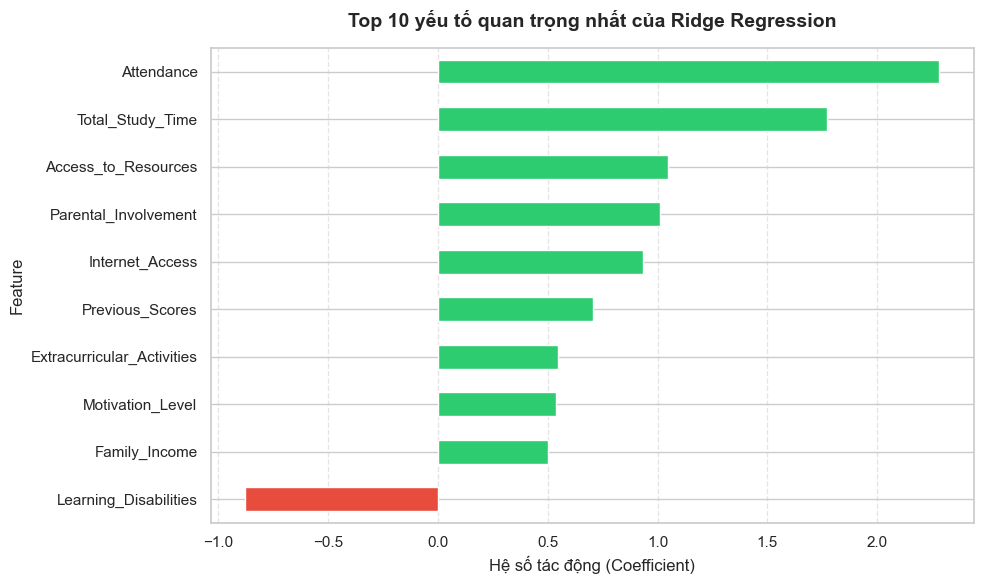

In [63]:
# 1. Lấy mô hình Ridge tốt nhất
best_ridge = ridge_grid.best_estimator_

# 2. Lấy tên cột từ tập encoded cuối cùng
encoded_feature_names = X_train_model_encoded.columns.tolist()

# 3. Hàm làm sạch tên hiển thị
def clean_display_name(name):
    clean_name = name.split("__")[-1]

    suffixes = [
        "_Yes", "_No",
        "_Male", "_Female",
        "_Public", "_Private",
        "_Urban", "_Rural"
    ]

    for s in suffixes:
        if clean_name.endswith(s):
            clean_name = clean_name.replace(s, "")

    return clean_name

display_names = [clean_display_name(name) for name in encoded_feature_names]

# 4. Tạo Series từ hệ số Ridge
coef_series = pd.Series(best_ridge.coef_, index=display_names)

# Nếu tên hiển thị bị trùng thì cộng dồn hệ số
coef_series = coef_series.groupby(level=0).sum()

# Lấy độ lớn tuyệt đối để xem mức ảnh hưởng mạnh yếu
coef_abs = coef_series.abs().sort_values(ascending=False)

# 5. Chọn top 10 feature quan trọng nhất
top_features = coef_abs.nlargest(10).index
top_coef = coef_series.loc[top_features].sort_values()

# 6. Màu theo chiều tác động
colors = ["#E74C3C" if val < 0 else "#2ECC71" for val in top_coef]

# 7. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
top_coef.plot(
    kind="barh",
    color=colors
)

plt.title("Top 10 yếu tố quan trọng nhất của Ridge Regression", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Hệ số tác động (Coefficient)")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


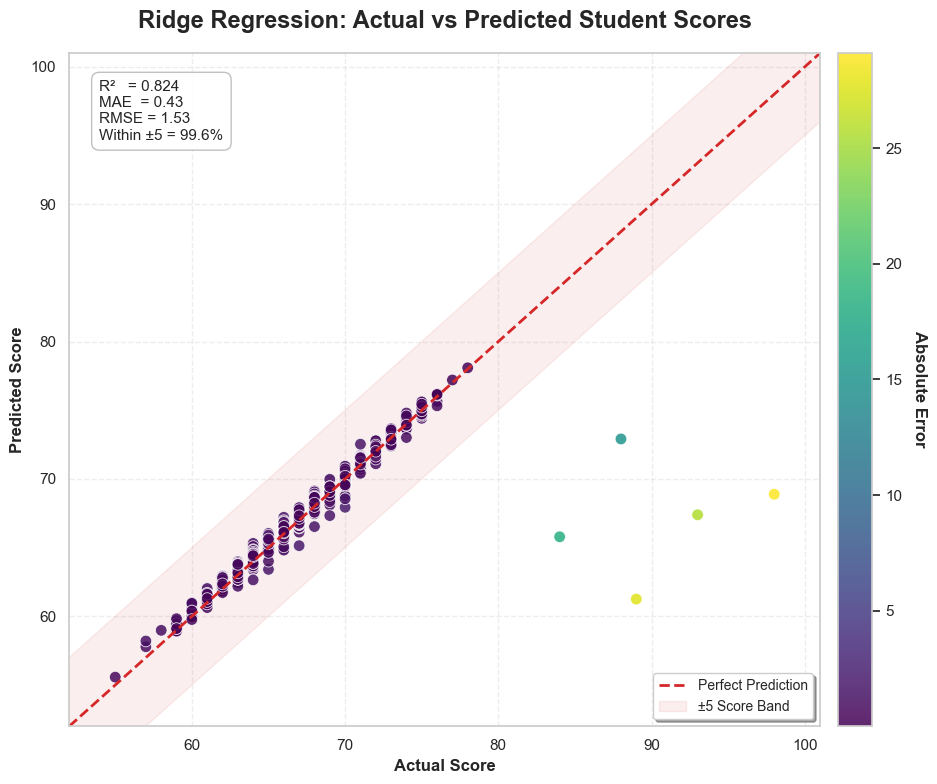

In [64]:
# =========================================================
# 1. FINAL MODEL: RIDGE
# =========================================================
best_ridge = ridge_grid.best_estimator_

# =========================================================
# 2. PREDICT ON TEST SET
# =========================================================
y_true = y_test.values if hasattr(y_test, "values") else y_test
y_pred = best_ridge.predict(X_test_model_encoded)

# =========================================================
# 3. METRICS
# =========================================================
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
abs_errors = np.abs(y_true - y_pred)
within_5 = (abs_errors <= 5).mean() * 100

# =========================================================
# 4. PLOT
# =========================================================
plt.figure(figsize=(10, 8))

min_val = min(y_true.min(), y_pred.min()) - 3
max_val = max(y_true.max(), y_pred.max()) + 3

# Perfect prediction line
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    color="#d62728",
    label="Perfect Prediction"
)

# Tolerance band ±5
tolerance = 5
plt.fill_between(
    [min_val, max_val],
    [min_val - tolerance, max_val - tolerance],
    [min_val + tolerance, max_val + tolerance],
    color="#d62728",
    alpha=0.08,
    label="±5 Score Band"
)

# Scatter
scatter = plt.scatter(
    y_true,
    y_pred,
    c=abs_errors,
    cmap="viridis",
    s=70,
    alpha=0.85,
    edgecolors="white",
    linewidth=0.6
)

# Colorbar
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label("Absolute Error", rotation=270, labelpad=18, fontweight="bold")

# Metrics box
metrics_text = (
    f"R²   = {r2:.3f}\n"
    f"MAE  = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}\n"
    f"Within ±5 = {within_5:.1f}%"
)

plt.text(
    0.04, 0.96,
    metrics_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        alpha=0.92,
        edgecolor="#bbbbbb"
    )
)

# Styling
plt.title("Ridge Regression: Actual vs Predicted Student Scores", fontsize=17, fontweight="bold", pad=18)
plt.xlabel("Actual Score", fontsize=12, fontweight="bold")
plt.ylabel("Predicted Score", fontsize=12, fontweight="bold")

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(loc="lower right", frameon=True, shadow=True, fontsize=10)
plt.tight_layout()
plt.show()


In [65]:
best_ridge = ridge_grid.best_estimator_

feature_engineer = FunctionTransformer(
    partial(
        feature_engineering_for_pipeline,
        raw_survivors=raw_survivors,
        raw_feature_names=list(X_train_for_model.columns),
    ),
    validate=False,
)

final_ridge = Ridge(alpha=ridge_grid.best_params_["alpha"], random_state=42)

full_pipeline_selected = Pipeline([
    ("feature_eng", feature_engineer),
    ("preprocess", preprocessor_selected),
    ("model", final_ridge),
])

full_pipeline_selected.fit(X_train_for_model, y_train_for_model)
y_pred_final_pipeline = full_pipeline_selected.predict(X_test_raw)

r2_final_pipeline = r2_score(y_test, y_pred_final_pipeline)
mae_final_pipeline = mean_absolute_error(y_test, y_pred_final_pipeline)
rmse_final_pipeline = mean_squared_error(y_test, y_pred_final_pipeline) ** 0.5

print("Final raw-input pipeline metrics:")
print(f"R2 Score: {r2_final_pipeline:.4f}")
print(f"MAE     : {mae_final_pipeline:.2f}")
print(f"RMSE    : {rmse_final_pipeline:.2f}")


Final raw-input pipeline metrics:
R2 Score: 0.8240
MAE     : 0.43
RMSE    : 1.53


# 8. Limitations
- Feature-selection thresholds hiện vẫn heuristic và nên được validate bằng cross-validation sạch hơn ở phase sau.
- Holdout test set đang được dùng cho model comparison, nên final metric nên được xem là project evidence, chưa phải locked production benchmark.
- Dataset schema validation và unknown-category handling cần harden thêm trước production.
- Ridge được chọn vì cân bằng deployability và explainability; đây là portfolio-oriented trade-off, không chứng minh Ridge luôn là model chính xác nhất.


# 9. Artifact Export and Smoke Check
Thứ tự đúng nên là: prepare export paths, export final pipeline, rồi reload artifact để smoke prediction. Phase 1 tắt export mặc định để tránh overwrite model trong lúc cleanup notebook.


In [66]:
# Safety flags for notebook review runs.
# Keep both False unless you intentionally want to write or reload artifacts.
EXPORT_ARTIFACTS = False
SMOKE_CHECK_EXPORTED_ARTIFACT = False


In [67]:
pipeline_path = MODELS_DIR / "hcmue_student_full_pipeline_v1_0.joblib"
export_metadata = {
    "model_name": "Ridge",
    "alpha": ridge_grid.best_params_["alpha"],
    "raw_feature_names": list(X_train_for_model.columns),
    "raw_survivors": raw_survivors,
    "metrics": {
        "r2": float(r2_final_pipeline),
        "mae": float(mae_final_pipeline),
        "rmse": float(rmse_final_pipeline),
    },
}

if EXPORT_ARTIFACTS:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(full_pipeline_selected, pipeline_path)
    joblib.dump(final_ridge, MODELS_DIR / "ridge_core_model.joblib")
    joblib.dump(list(X_train_for_model.columns), MODELS_DIR / "raw_feature_names.joblib")
    joblib.dump(raw_survivors, MODELS_DIR / "raw_survivors.joblib")

    with open(MODELS_DIR / "best_hyperparameters.json", "w", encoding="utf-8") as f:
        json.dump(
            {"model_name": "Ridge", "alpha": ridge_grid.best_params_["alpha"]},
            f,
            indent=4,
            ensure_ascii=False,
        )

    with open(MODELS_DIR / "model_metadata.json", "w", encoding="utf-8") as f:
        json.dump(export_metadata, f, indent=4, ensure_ascii=False)

    print(f"Exported artifacts to: {MODELS_DIR}")
else:
    print("Artifact export skipped. Set EXPORT_ARTIFACTS=True to write files.")


Artifact export skipped. Set EXPORT_ARTIFACTS=True to write files.


In [68]:
if SMOKE_CHECK_EXPORTED_ARTIFACT:
    loaded_pipeline = joblib.load(pipeline_path)
    sample_input_ultra = {
        "Hours_Studied": 12,
        "Attendance": 100,
        "Parental_Involvement": "High",
        "Access_to_Resources": "High",
        "Extracurricular_Activities": "Yes",
        "Sleep_Hours": 8,
        "Previous_Scores": 100,
        "Motivation_Level": "High",
        "Internet_Access": "Yes",
        "Tutoring_Sessions": 12,
        "Family_Income": "High",
        "Teacher_Quality": "High",
        "School_Type": "Public",
        "Peer_Influence": "Positive",
        "Physical_Activity": 8,
        "Learning_Disabilities": "No",
        "Parental_Education_Level": "Postgraduate",
        "Distance_from_Home": "Near",
        "Gender": "Male",
    }
    sample_df_ultra = pd.DataFrame([sample_input_ultra], columns=X_train_for_model.columns)
    pred_ultra_loaded = loaded_pipeline.predict(sample_df_ultra)
    print("Prediction from loaded pipeline:", pred_ultra_loaded)
else:
    print("Smoke check skipped. Set SMOKE_CHECK_EXPORTED_ARTIFACT=True after exporting.")


Smoke check skipped. Set SMOKE_CHECK_EXPORTED_ARTIFACT=True after exporting.
